# Implementation of MedSAM2 with Test-Time Augmentation

*   Github: https://github.com/bowang-lab/MedSAM2
*   Ma, J., Yang, Z., Kim, S., Chen, B., Baharoon, M., Fallahpour, A., ... & Wang, B. (2025). Medsam2: Segment anything in 3d medical images and videos. arXiv preprint arXiv:2504.03600.






## 1 - Environment Setup and Model Checkpoint Download

**Purpose:** Initialize MedSAM2 environment and download pre-trained medical segmentation models.

**Setup Process:**
- Clones MedSAM2 repository and installs dependencies
- Downloads all available model checkpoints via official script
- Mounts Google Drive for dataset access

**Available Models:**
- `MedSAM2_2411.pt`: Base general-purpose model
- `MedSAM2_US_Heart.pt`: Cardiac ultrasound specialized
- `MedSAM2_MRI_LiverLesion.pt`: Liver MRI specialized
- `MedSAM2_CTLesion.pt`: CT lesion specialized
- `MedSAM2_latest.pt`: Latest recommended version

**Output:** Displays downloaded checkpoints with file sizes and usage recommendations for specific medical imaging tasks.

In [ ]:
# ============================================
# Cell 1: Environment Setup with ALL MedSAM2 Checkpoints
# ============================================
# Run this cell first to set up the environment
# Make sure to use GPU: Runtime → Change runtime type → GPU

# Install dependencies
!git clone https://github.com/bowang-lab/MedSAM2.git
%cd MedSAM2
%pip install -e .
# Install additional dependencies for metrics calculation
!pip install medpy

# Download ALL available model checkpoints
!mkdir -p checkpoints

print("Downloading all available MedSAM2 checkpoints...")

# Location of the download script
!wget https://raw.githubusercontent.com/bowang-lab/MedSAM2/main/download.sh
!chmod +x download.sh

# Run the download script to fetch all checkpoints
!./download.sh

# Alternatively, download each checkpoint manually (if the script above fails)
"""
# Fallback: manually download each checkpoint
checkpoints_to_download = {
    "MedSAM2_2411.pt": "Base model (November 2024)",
    "MedSAM2_US_Heart.pt": "Dedicated to cardiac ultrasound video segmentation",
    "MedSAM2_MRI_LiverLesion.pt": "Dedicated to liver lesion MRI segmentation",
    "MedSAM2_CTLesion.pt": "Dedicated to CT lesion segmentation",
    "MedSAM2_latest.pt": "Latest recommended model"
}

# If automatic download fails, uncomment the code below to download manually
# for checkpoint_name, description in checkpoints_to_download.items():
#     print(f"\nDownloading {checkpoint_name} - {description}")
#     # Replace with the actual download URL (check GitHub for the latest links)
#     !wget -P checkpoints [specific_download_URL]
"""

# List all downloaded checkpoints
import os
checkpoint_files = sorted([f for f in os.listdir('checkpoints') if f.endswith('.pt')])
print(f"\nSuccessfully downloaded checkpoint files:")
for i, ckpt in enumerate(checkpoint_files):
    file_size = os.path.getsize(os.path.join('checkpoints', ckpt)) / (1024**2)
    print(f"{i+1}. {ckpt} ({file_size:.1f} MB)")

# Checkpoint descriptions
print("\n" + "="*60)
print("Checkpoint file descriptions:")
print("="*60)
print("1. MedSAM2_2411.pt - General-purpose base model")
print("2. MedSAM2_US_Heart.pt - Cardiac ultrasound only (not suitable for CT vascular data)")
print("3. MedSAM2_MRI_LiverLesion.pt - Dedicated to liver MRI lesion segmentation")
print("4. MedSAM2_CTLesion.pt - CT lesion dedicated (may be suitable)")
print("5. MedSAM2_latest.pt - Latest model (recommended)")
print("\nFor liver vascular CT data, recommended checkpoints to try first:")
print("- MedSAM2_latest.pt (latest version)")
print("- MedSAM2_CTLesion.pt (CT-specific)")
print("- MedSAM2_2411.pt (base version)")


Cloning into 'MedSAM2'...
remote: Enumerating objects: 297, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 297 (delta 90), reused 63 (delta 63), pack-reused 144 (from 1)
Receiving objects: 100% (297/297), 18.82 MiB | 9.37 MiB/s, done.
Resolving deltas: 100% (122/122), done.
/content/MedSAM2
Obtaining file:///content/MedSAM2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 41.4 MB/s eta 0:00:00
  Building editable for MedSAM2 (pyproject.toml) ... done
  Created wheel for MedSAM2: filename=medsam2-1.0-0.edita

In [ ]:
# ============================================
# Cell 1.1: Google drive
# ============================================
# Mount Google Drive to access custom dataset
from google.colab import drive
drive.mount('/content/drive')
print("\nSetup complete!")

Mounted at /content/drive

Setup complete!


## 2 - Library Import and Function Definitions

**Purpose:** Import necessary libraries and define core functions for medical image segmentation with MedSAM2.

**Key Libraries:**
- Image processing: PIL, SimpleITK, scikit-image
- Deep learning: PyTorch, SAM2
- Evaluation: medpy (for HD95 metric)
- Utilities: numpy, pandas, matplotlib

**Core Functions:**
- `getLargestCC()`: Extract largest connected component from segmentation
- `show_mask()`, `show_box()`: Visualization utilities for masks and bounding boxes
- `resize_grayscale_to_rgb_and_resize()`: Convert grayscale medical images to RGB format required by SAM2
- `get_bounding_box_from_mask()`: Extract bounding box coordinates from binary mask

**Evaluation Functions:**
- `calculate_metrics()`: Compute IoU, Dice, and HD95 for binary segmentation
- `calculate_metrics_per_class()`: Per-class IoU and Dice for multi-class segmentation
- `calculate_metrics_force_multiclass()`: Handle multi-class evaluation when prediction is binary, computing mIoU, aIoU, mDice, aDice

**Configuration:**
- Sets random seeds for reproducibility
- Configures PyTorch for high precision matrix multiplication

In [ ]:
# ============================================
# Cell 2: Import libraries and define functions
# ============================================
# Import all necessary libraries
from glob import glob
from tqdm import tqdm
import os
from os.path import join, basename
import re
import matplotlib.pyplot as plt
from collections import OrderedDict
import pandas as pd
import numpy as np
import argparse
import json

from PIL import Image
import SimpleITK as sitk
import torch
import torch.multiprocessing as mp
from sam2.build_sam import build_sam2_video_predictor_npz
import SimpleITK as sitk
from skimage import measure, morphology
from medpy.metric.binary import hd95 as compute_hd95
from datetime import datetime

torch.set_float32_matmul_precision('high')
torch.manual_seed(2024)
torch.cuda.manual_seed(2024)
np.random.seed(2024)


def getLargestCC(segmentation):
    labels = measure.label(segmentation)
    largestCC = labels == np.argmax(np.bincount(labels.flat)[1:])+1
    return largestCC

def show_mask(mask, ax, mask_color=None, alpha=0.5):
    """
    show mask on the image

    Parameters
    ----------
    mask : numpy.ndarray
        mask of the image
    ax : matplotlib.axes.Axes
        axes to plot the mask
    mask_color : numpy.ndarray
        color of the mask
    alpha : float
        transparency of the mask
    """
    if mask_color is not None:
        color = np.concatenate([mask_color, np.array([alpha])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, alpha])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_box(box, ax, edgecolor='blue'):
    """
    show bounding box on the image

    Parameters
    ----------
    box : numpy.ndarray
        bounding box coordinates in the original image
    ax : matplotlib.axes.Axes
        axes to plot the bounding box
    edgecolor : str
        color of the bounding box
    """
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor=edgecolor, facecolor=(0,0,0,0), lw=2))


def resize_grayscale_to_rgb_and_resize(array, image_size):
    """
    Resize a 3D grayscale NumPy array to an RGB image and then resize it.

    Parameters:
        array (np.ndarray): Input array of shape (d, h, w).
        image_size (int): Desired size for the width and height.

    Returns:
        np.ndarray: Resized array of shape (d, 3, image_size, image_size).
    """
    d, h, w = array.shape
    resized_array = np.zeros((d, 3, image_size, image_size))

    for i in range(d):
        img_pil = Image.fromarray(array[i].astype(np.uint8))
        img_rgb = img_pil.convert("RGB")
        img_resized = img_rgb.resize((image_size, image_size))
        img_array = np.array(img_resized).transpose(2, 0, 1)  # (3, image_size, image_size)
        resized_array[i] = img_array

    return resized_array

# Add metrics calculation functions
def calculate_metrics(pred, gt):
    """
    Calculate segmentation metrics: IoU, Dice, and HD95

    Parameters:
        pred: predicted segmentation mask (binary)
        gt: ground truth segmentation mask (binary)

    Returns:
        dict: containing IoU, Dice, and HD95 metrics
    """
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    # Calculate intersection and union
    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    # IoU
    iou = intersection / (union + 1e-8)

    # Dice
    dice = 2 * intersection / (pred.sum() + gt.sum() + 1e-8)

    # HD95 - handle edge cases
    try:
        if pred.sum() > 0 and gt.sum() > 0:
            hd95_score = compute_hd95(pred, gt)
        else:
            hd95_score = np.inf
    except:
        hd95_score = np.inf

    return {
        'iou': iou,
        'dice': dice,
        'hd95': hd95_score
    }

# Calculate per-class IoU and Dice
def calculate_metrics_per_class(pred_binary, gt_multiclass):
  per_class_iou = {}
  per_class_dice = {}

  unique_labels = np.unique(gt_multiclass)
  unique_labels = unique_labels[unique_labels > 0]

  for label in unique_labels:
        # Current class in GT
        gt_class = (gt_multiclass == label).astype(bool)

        # Prediction pixels overlapping the current GT class are treated as that class's prediction
        pred_class = np.logical_and(pred_binary > 0, gt_class)

        # Compute IoU for this class
        intersection = np.logical_and(pred_class, gt_class).sum()
        union = np.logical_or(pred_class, gt_class).sum()

        if union > 0:
            iou = intersection / union
        else:
            iou = 0.0

        # Compute Dice for this class
        if (pred_class.sum() + gt_class.sum()) > 0:
            dice = 2 * intersection / (pred_class.sum() + gt_class.sum())
        else:
            dice = 0.0

        per_class_iou[int(label)] = iou
        per_class_dice[int(label)] = dice
  return per_class_iou, per_class_dice

# Add new calculation function
def calculate_metrics_force_multiclass(pred_binary, gt_multiclass):
    """
    Force multi-class metric computation even when predictions are binary,
    by assigning predicted foreground pixels to each GT class.
    """
    # Get all foreground classes (excluding background 0)
    unique_labels = np.unique(gt_multiclass)
    unique_labels = unique_labels[unique_labels > 0]

    if len(unique_labels) == 0:
        return {
            'mIoU': 0.0,
            'aIoU': 0.0,
            'mDice': 0.0,
            'aDice': 0.0,
            'hd95': np.inf
        }

    # Assign predictions to each GT class
    per_class_iou, per_class_dice = calculate_metrics_per_class(pred_binary, gt_multiclass)

    # Compute mIoU (simple mean)
    mIoU = np.mean(list(per_class_iou.values()))

    # Compute mDice (simple mean)
    mDice = np.mean(list(per_class_dice.values()))

    # Compute class-agnostic metrics
    # Merge all foreground classes into a single binary class
    # Map labels [0, 1, 2] -> [0, 1, 1] to compute aIoU and aDice
    a_gt_multiclass = gt_multiclass.copy()
    a_gt_multiclass[a_gt_multiclass == 2] = 1  # Merge class 2 into class 1
    a_per_class_iou, a_per_class_dice = calculate_metrics_per_class(pred_binary, a_gt_multiclass)


    # Compute aIoU
    aIoU = np.mean(list(a_per_class_iou.values()))

    # Compute aDice
    aDice = np.mean(list(a_per_class_dice.values()))


    # Old: Compute aIoU (weighted average)
    # total_pixels = 0
    # weighted_iou = 0
    # for label in unique_labels:
    #     gt_pixels = (gt_multiclass == label).sum()
    #     total_pixels += gt_pixels
    #     weighted_iou += per_class_iou[int(label)] * gt_pixels

    # aIoU = weighted_iou / total_pixels if total_pixels > 0 else 0.0

    # Old: Compute aDice (weighted average)
    # weighted_dice = 0
    # for label in unique_labels:
    #     gt_pixels = (gt_multiclass == label).sum()
    #     weighted_dice += per_class_dice[int(label)] * gt_pixels

    # aDice = weighted_dice / total_pixels if total_pixels > 0 else 0.0

    # HD95 (computed on the overall binary mask)
    gt_binary = (gt_multiclass > 0).astype(bool)
    pred_binary_bool = pred_binary.astype(bool)

    try:
        if pred_binary_bool.sum() > 0 and gt_binary.sum() > 0:
            hd95_score = compute_hd95(pred_binary_bool, gt_binary)
        else:
            hd95_score = np.inf
    except:
        hd95_score = np.inf

    return {
        'mIoU': mIoU,
        'aIoU': aIoU,
        'mDice': mDice,
        'aDice': aDice,
        'hd95': hd95_score,
        'per_class_iou': per_class_iou,
        'per_class_dice': per_class_dice
    }

def get_bounding_box_from_mask(mask):
    """
    Get bounding box from binary mask

    Parameters:
        mask: binary mask

    Returns:
        bbox: [x_min, y_min, x_max, y_max] or None if mask is empty
    """
    if mask.sum() == 0:
        return None

    positions = np.where(mask)
    y_min = positions[0].min()
    y_max = positions[0].max()
    x_min = positions[1].min()
    x_max = positions[1].max()

    return np.array([x_min, y_min, x_max, y_max])

print("Functions loaded successfully!")


Functions loaded successfully!


In [ ]:
# reset working dir if need
!pwd
%cd 'MedSAM2'
!ls

## 3 - Path Configuration and Checkpoint Selection

**Purpose:** Configure dataset paths, select model checkpoint, and set up output directories for experiment results.

**Checkpoint Selection:**
- Lists all available MedSAM2 checkpoints with descriptions and file sizes
- Allows selection by direct name specification or index
- Verifies checkpoint existence before proceeding

**Dataset Configuration:**
- Sets paths for medical imaging dataset
- Configures image and label directories
- Supports augmentation options: gamma correction, contrast enhancement, Gaussian blur, noise injection

**Output Directory Structure:**
- Creates timestamped result directories with checkpoint-specific naming
- Organizes outputs into three subdirectories:
 - `predictions/`: Segmentation masks
 - `visualizations/`: PNG visualization images
 - `metrics/`: Performance metrics (JSON/CSV)

**Key Features:**
- Automatic file counting and validation
- Provides experiment configuration summary
- Creates unique result folders for different checkpoints and experiments

**Output:** Displays selected checkpoint, dataset statistics, and complete directory structure for organized result storage.

In [ ]:
# ============================================
# Cell 3: Set paths and select checkpoint
# ============================================

import os

# List all available checkpoints
checkpoint_dir = './checkpoints'
available_checkpoints = sorted([f for f in os.listdir(checkpoint_dir) if f.endswith('.pt')])

# Checkpoint descriptions
checkpoint_descriptions = {
    "MedSAM2_2411.pt": "General-purpose base model",
    "MedSAM2_US_Heart.pt": "Cardiac ultrasound dedicated",
    "MedSAM2_MRI_LiverLesion.pt": "Liver MRI lesion dedicated",
    "MedSAM2_CTLesion.pt": "CT lesion dedicated - Recommended",
    "MedSAM2_latest.pt": "Latest model - Strongly recommended"
}

print("Available checkpoint files:")
print("="*60)
for i, ckpt in enumerate(available_checkpoints):
    file_size = os.path.getsize(os.path.join(checkpoint_dir, ckpt)) / (1024**2)
    desc = checkpoint_descriptions.get(ckpt, "Unknown model")
    print(f"{i+1}. {ckpt} ({file_size:.1f} MB)")
    print(f"   {desc}")
print("="*60)

# ========== Select the checkpoint to use here ==========
# Method 1: Specify checkpoint name directly (recommended)
CHECKPOINT_NAME = "MedSAM2_MRI_LiverLesion.pt"  # <-- Change this to switch checkpoints

# Method 2: Select by index (uncomment to use)
# checkpoint_index = 4  # Select the 5th checkpoint (MedSAM2_latest.pt)
# CHECKPOINT_NAME = available_checkpoints[checkpoint_index]

print(f"\nSelected checkpoint: {CHECKPOINT_NAME}")
print(f"Description: {checkpoint_descriptions.get(CHECKPOINT_NAME, 'Unknown model')}")

# Set checkpoint path
checkpoint = os.path.join(checkpoint_dir, CHECKPOINT_NAME)
if not os.path.exists(checkpoint):
    print(f"\nError: checkpoint file {checkpoint} does not exist!")
    print("Please make sure Cell 1 has been run to download all checkpoints")
else:
    print(f"\nCheckpoint path: {checkpoint}")
    print("✓ Checkpoint exists, ready to proceed")

# Model configuration
model_cfg = "configs/sam2.1_hiera_t512.yaml"


# ========== Select the augmentation method to use here ==========
images_augmentation = {
  'augmentation_gamma_correction': 'Gamma Correction: adjusts the global brightness curve (nonlinear), gamma randomly sampled from 0.8-1.2',
  'augmentation_contrast_enhancement': 'Contrast Enhancement: linear scaling with alpha randomly sampled from 1.1-1.3 (moderate enhancement, no pixel saturation)',
  'augmentation_gaussian_blur': 'Gaussian Blur: sigma randomly sampled from 0.5-1.5 (mild smoothing, lesion structure preserved)',
  'augmentation_noise': 'Gaussian Noise Injection: noise std set to 5%-10% of image std (subtle noise, lesion visibility preserved)'
}

# Set timestamp
timestamp = datetime.now().strftime("%m%d")

# augmentation path
aug_type = 'augmentation_noise' # <-- Change this to switch augmentation type
augmentation_var = f'{aug_type}_{timestamp}'

# Custom dataset paths from Google Drive
dataset_name = 'UterUS'
path = {
    'dataset': '/content/drive/MyDrive/SegTTA-SCI/dataset/UterUS/dataset',
    'result': '/content/drive/MyDrive/SegTTA-SCI/results/UterUS'
}


# Annotation label path
labels_path = os.path.join(path['dataset'], 'annotations')

# Volume/image path
imgs_path = os.path.join(path['result'], augmentation_var) if aug_type else os.path.join(path['dataset'], 'annotated_volumes')

dataset_path = os.path.join(path['result'], augmentation_var) if aug_type else path['dataset']


# Output paths - create separate result folders based on checkpoint name/augmentation method
checkpoint_suffix = CHECKPOINT_NAME.replace('.pt', '').replace('MedSAM2_', '')

# Prediction save path
pred_save_dir = os.path.join(path['result'], f'MedSAM2_results_{checkpoint_suffix}_{augmentation_var}') if aug_type else os.path.join(path['result'], f'MedSAM2_results_{checkpoint_suffix}_{timestamp}')


os.makedirs(pred_save_dir, exist_ok=True)
print(f"Results will be saved to: {pred_save_dir}")

# Create subfolders to organize different output types
predictions_dir = os.path.join(pred_save_dir, 'predictions')
visualizations_dir = os.path.join(pred_save_dir, 'visualizations')
metrics_dir = os.path.join(pred_save_dir, 'metrics')

os.makedirs(predictions_dir, exist_ok=True)
os.makedirs(visualizations_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

# Update metrics save path
metrics_save_path = os.path.join(metrics_dir, 'performance_metrics.json')

# Get list of all image files
image_files = sorted([f for f in os.listdir(imgs_path) if f.endswith('.nii.gz') and not f.startswith('._')])
print(f"\nFound {len(image_files)} real images in the dataset")

if len(image_files) == 0:
    print("No valid image files found!")
    print("Checking directory contents...")
    all_files = os.listdir(imgs_path)
    print(f"Total files in directory: {len(all_files)}")
    print("Sample files:", all_files[:10])
else:
    print("Sample image files:", image_files[:5])

# Also check label files
label_files = sorted([f for f in os.listdir(labels_path) if f.endswith('.nii.gz') and not f.startswith('._')])
print(f"Found {len(label_files)} real labels in the dataset")

if aug_type:
  print(f'Current dataset: {dataset_path}')
else:
  print("\nDirectory structure created:")
  print(f"├── {dataset_path}/")
  print(f"│   ├── MedSAM2_results_{checkpoint_suffix}/")
  print(f"│   │   ├── predictions/     (segmentation masks)")
  print(f"│   │   ├── visualizations/  (PNG images)")
  print(f"│   │   └── metrics/         (JSON and CSV files)")

# Experiment configuration summary
print("\n" + "="*60)
print("Experiment configuration summary:")
print("="*60)
print(f"Checkpoint: {CHECKPOINT_NAME}")
print(f"Dataset: {dataset_name} ({len(image_files)} files)")
print(f"Results will be saved to: {pred_save_dir}")
print("="*60)

可用的权重文件 (Available checkpoints):
1. MedSAM2_2411.pt (148.8 MB)
   基础通用模型 (Base model)
2. MedSAM2_CTLesion.pt (148.8 MB)
   CT病变专用 (CT lesion) - 推荐
3. MedSAM2_MRI_LiverLesion.pt (148.8 MB)
   肝脏MRI病变专用 (Liver MRI lesion)
4. MedSAM2_US_Heart.pt (148.8 MB)
   心脏超声专用 (Heart ultrasound)
5. MedSAM2_latest.pt (148.8 MB)
   最新模型 (Latest) - 强烈推荐
6. efficienttam_s_512x512.pt (130.1 MB)
   未知模型
7. efficienttam_ti_512x512.pt (68.3 MB)
   未知模型
8. sam2.1_hiera_tiny.pt (148.8 MB)
   未知模型

当前选择的权重: MedSAM2_MRI_LiverLesion.pt
说明: 肝脏MRI病变专用 (Liver MRI lesion)

权重文件路径: ./checkpoints/MedSAM2_MRI_LiverLesion.pt
✓ 权重文件存在，可以继续运行
Results will be saved to: /content/drive/MyDrive/SegTTA-SCI/results/UterUS/MedSAM2_results_MRI_LiverLesion_augmentation_noise_0824


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SegTTA-SCI/results/UterUS/augmentation_noise_0824'

## 4 - Inference on Custom Dataset

**Purpose:** Run MedSAM2 inference on medical imaging dataset and evaluate segmentation performance.

**Workflow:**
1. **Initialize Model:** Build SAM2 video predictor with selected checkpoint
2. **Process Each Image:**
  - Load NIfTI image and corresponding label
  - Normalize image values to 0-255 range
  - Find key slice (slice with largest label area)
  - Extract bounding box from ground truth mask
  - Resize and prepare image for SAM2 (512x512 RGB format)

3. **Segmentation Process:**
  - Initialize segmentation state with processed image
  - Add bounding box prompt at key slice
  - Perform bidirectional propagation (forward and backward) across all slices
  - Apply post-processing (extract largest connected component)

4. **Evaluation:**
  - Calculate multi-class metrics: mIoU, aIoU, mDice, aDice, HD95
  - Handle multi-class evaluation even with binary predictions
  - Store results for each image

**Key Features:**
- Automatic label file matching with fallback naming conventions
- GPU-accelerated inference with mixed precision (bfloat16)
- Robust error handling for missing files or invalid data
- Saves predictions as NIfTI files preserving original metadata

**Output:** Segmentation masks saved to predictions directory and performance metrics stored for analysis.

**Experiment Design:**
1.  This cell needs to be executed 9 times according to project requirements.
2.  The first 5 runs test all available checkpoints on baseline images to identify the best-performing model.
3.  The remaining 4 runs apply the optimal checkpoint to images with different augmentation methods (gamma correction, contrast enhancement, Gaussian blur, noise injection) to evaluate robustness.

In [ ]:
# ============================================
# Cell 4: Run Inference on Custom Dataset
# ============================================
# Initialize predictor
predictor = build_sam2_video_predictor_npz(model_cfg, checkpoint)

# Storage for metrics
all_metrics = []
seg_info = OrderedDict()
seg_info['image_name'] = []
seg_info['mIoU'] = []   # renamed
seg_info['aIoU'] = []   # newly added
seg_info['mDice'] = []  # renamed
seg_info['aDice'] = []  # newly added
seg_info['hd95'] = []

def extract_prefix(filename):
    """
    Extract the prefix portion of a filename (name + numeric ID).

    Examples:
    'hepaticvessel_001.nii.gz' -> 'hepaticvessel_001'
    'hepaticvessel_001_gamma0.95.nii.gz' -> 'hepaticvessel_001'
    """
    # Method 1: Match "<name>_<digits>" pattern
    pattern = r'^([a-zA-Z]+_\d{3})'
    match = re.match(pattern, filename)
    if match:
        return match.group(1)

    return None

# Process each image
for img_name in tqdm(image_files, desc="Processing images"):
    try:
        # Load image and corresponding label
        img_path = os.path.join(imgs_path, img_name)

        # Find the corresponding label based on the naming convention
        # (assuming image and label share the same filename)
        label_name = img_name
        label_path = os.path.join(labels_path, label_name)

        # Check if the label file exists
        if not os.path.exists(label_path):
            print(f"Label not found for {img_name}, trying alternative names...")
            # Try alternative naming conventions
            # e.g., hepaticvessel_001.nii.gz -> hepaticvessel_001_label.nii.gz
            alternative_names = [
                img_name.replace('.nii.gz', '_label.nii.gz'),
                'label_' + img_name,
                img_name.replace('image', 'label'),
            ]

            for alt_name in alternative_names:
                alt_path = os.path.join(labels_path, alt_name)
                if os.path.exists(alt_path):
                    label_path = alt_path
                    print(f"Found label: {alt_name}")
                    break
            else:
                print(f"Skipping {img_name}: No corresponding label found")
                continue

        # Read image and label
        nii_image = sitk.ReadImage(img_path)
        nii_image_data = sitk.GetArrayFromImage(nii_image)

        nii_label = sitk.ReadImage(label_path)
        nii_label_data = sitk.GetArrayFromImage(nii_label)

        # test label change
        # unique_label_1 = np.unique(nii_label_data)
        # print(unique_label_1)
        # test_nii_label_data = nii_label_data.copy()
        # test_nii_label_data[test_nii_label_data == 2] = 1
        # print(np.unique(test_nii_label_data))

        # # Merge class 2 into 1 for binary segmentation
        # nii_label_data[nii_label_data == 2] = 1
        # print(np.unique(nii_label_data))

        # Preprocess image (normalize to 0-255)
        nii_image_data_pre = nii_image_data.astype(np.float32)
        nii_image_data_pre = np.clip(nii_image_data_pre, np.percentile(nii_image_data_pre, 0.5),
                                     np.percentile(nii_image_data_pre, 99.5))
        nii_image_data_pre = (nii_image_data_pre - np.min(nii_image_data_pre)) / \
                             (np.max(nii_image_data_pre) - np.min(nii_image_data_pre)) * 255.0
        nii_image_data_pre = np.uint8(nii_image_data_pre)

        # Find key slice (slice with largest label area)
        label_areas = np.sum(nii_label_data > 0, axis=(1, 2))
        if label_areas.sum() == 0:
            print(f"Skipping {img_name}: No label found")
            continue

        key_slice_idx = np.argmax(label_areas)

        # Get bounding box from label
        key_slice_label = nii_label_data[key_slice_idx]
        bbox = get_bounding_box_from_mask(key_slice_label > 0)

        if bbox is None:
            print(f"Skipping {img_name}: No valid bounding box")
            continue

        # Prepare image for SAM2
        img_3D_ori = nii_image_data_pre
        video_height = img_3D_ori.shape[1]
        video_width = img_3D_ori.shape[2]

        img_resized = resize_grayscale_to_rgb_and_resize(img_3D_ori, 512)
        img_resized = img_resized / 255.0
        img_resized = torch.from_numpy(img_resized).cuda()

        # Normalize
        img_mean = (0.485, 0.456, 0.406)
        img_std = (0.229, 0.224, 0.225)
        img_mean = torch.tensor(img_mean, dtype=torch.float32)[:, None, None].cuda()
        img_std = torch.tensor(img_std, dtype=torch.float32)[:, None, None].cuda()
        img_resized -= img_mean
        img_resized /= img_std

        # Initialize segmentation
        segs_3D = np.zeros(nii_image_data.shape, dtype=np.uint8)

        # Run inference
        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            inference_state = predictor.init_state(img_resized, video_height, video_width)

            # Add box prompt at key slice
            _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=key_slice_idx,
                obj_id=1,
                box=bbox,
            )

            # Forward propagation
            for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
                segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1

            predictor.reset_state(inference_state)

            # Re-add box prompt for backward propagation
            _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=key_slice_idx,
                obj_id=1,
                box=bbox,
            )

            # Backward propagation
            for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state, reverse=True):
                segs_3D[out_frame_idx, (out_mask_logits[0] > 0.0).cpu().numpy()[0]] = 1

            predictor.reset_state(inference_state)

        # Post-processing
        if np.max(segs_3D) > 0:
            segs_3D = getLargestCC(segs_3D)
            segs_3D = np.uint8(segs_3D)

        # Calculate metrics using the multi-class computation method
        # Note: using original multi-class labels, not a binary label
        metrics = calculate_metrics_force_multiclass(segs_3D, nii_label_data)

        # Store results - save all metrics
        seg_info['image_name'].append(img_name)
        seg_info['mIoU'].append(metrics['mIoU'])
        seg_info['aIoU'].append(metrics['aIoU'])
        seg_info['mDice'].append(metrics['mDice'])
        seg_info['aDice'].append(metrics['aDice'])
        seg_info['hd95'].append(metrics['hd95'])
        all_metrics.append(metrics)

        # Print result for this image
        print(f"Processed {img_name}: mIoU={metrics['mIoU']:.4f}, aIoU={metrics['aIoU']:.4f}, "
              f"mDice={metrics['mDice']:.4f}, aDice={metrics['aDice']:.4f}")

        # Save segmentation to the predictions folder
        sitk_mask = sitk.GetImageFromArray(segs_3D)
        sitk_mask.CopyInformation(nii_image)
        save_name = img_name.replace('.nii.gz', '_pred.nii.gz')
        sitk.WriteImage(sitk_mask, os.path.join(predictions_dir, save_name))

        # print(f"Processed {img_name}: IoU={metrics['iou']:.4f}, Dice={metrics['dice']:.4f}")

    except Exception as e:
        print(f"Error processing {img_name}: {str(e)}")
        continue

propagate in video: 100%|██████████| 62/62 [00:01<00:00, 37.47it/s]

Processing images:   1%|          | 1/141 [00:20<48:47, 20.91s/it]

Processed 04_01.nii.gz: mIoU=0.8429, aIoU=0.8429, mDice=0.9148, aDice=0.9148



propagate in video: 100%|██████████| 74/74 [00:01<00:00, 38.33it/s]

Processing images:   1%|▏         | 2/141 [00:33<37:28, 16.17s/it]

Processed 04_02.nii.gz: mIoU=0.7497, aIoU=0.7497, mDice=0.8569, aDice=0.8569



propagate in video: 100%|██████████| 81/81 [00:02<00:00, 37.93it/s]

Processing images:   2%|▏         | 3/141 [00:51<38:57, 16.94s/it]

...

Processed 22_57.nii.gz: mIoU=0.8039, aIoU=0.8039, mDice=0.8913, aDice=0.8913



propagate in video: 100%|██████████| 42/42 [00:01<00:00, 32.38it/s]

Processing images:  99%|█████████▉| 140/141 [26:19<00:09,  9.17s/it]

Processed 22_58.nii.gz: mIoU=0.8782, aIoU=0.8782, mDice=0.9351, aDice=0.9351



propagate in video: 100%|██████████| 38/38 [00:00<00:00, 38.29it/s]

Processing images: 100%|██████████| 141/141 [26:33<00:00, 11.30s/it]

Processed 22_59.nii.gz: mIoU=0.8328, aIoU=0.8328, mDice=0.9088, aDice=0.9088


In [ ]:
# ============================================
# Cell 4.1: Simpele Check Data
# ============================================
print(seg_info['mIoU'])
print(seg_info['aIoU'])
print(seg_info['mDice'])
print(seg_info['aDice'])
print(seg_info['hd95'])

[np.float64(0.8429401251117069), np.float64(0.7496760591219555), np.float64(0.8522112143805536), np.float64(0.8844713852736673), np.float64(0.8958575691669617), np.float64(0.6820025815969021), np.float64(0.5380939149763824), np.float64(0.9538423266543037), np.float64(0.7218535197914198), np.float64(0.8874417662548106), np.float64(0.8172073899850979), np.float64(0.8795239847871427), np.float64(0.8975659229208925), np.float64(0.8923547400611621), np.float64(0.9602062765429376), np.float64(0.6280711971754086), np.float64(0.7270461154964686), np.float64(0.9487141502725764), np.float64(0.8613502109704642), np.float64(0.7888895180927572), np.float64(0.40209219858156026), np.float64(0.7844388935146637), np.float64(0.9162680788065141), np.float64(0.8587820705659891), np.float64(0.8652269192704651), np.float64(0.7190127845764682), np.float64(0.9173502479969478), np.float64(0.7572261827608555), np.float64(0.8195144562257373), np.float64(0.8836569857363809), np.float64(0.9244006568144499), np.flo

## 5 & 6 - Performance Metrics Calculation and Visualization

**Purpose:** Calculate final performance metrics, generate comprehensive visualizations, and create detailed reports for segmentation results.

**Metrics Calculation:**
- Verifies metric relationships (aIoU ≥ mIoU, aDice ≥ mDice) to ensure calculation correctness
- Aggregates performance across all processed cases: mIoU, aIoU, mDice, aDice, and HD95
- Handles invalid measurements (e.g., infinite HD95 values) appropriately

**Visualization Pipeline:**
- Automatically identifies best-performing cases based on mDice scores
- Creates multi-panel visualizations showing: Original Image | Ground Truth (Multi-class) | Prediction (Binary)
- Color-codes different vessel classes in ground truth: Green (Class 1), Blue (Class 2)
- Generates visualizations for top 5 performing cases with performance metrics

**Report Generation:**
- **JSON metrics file:** Aggregated performance statistics
- **CSV detailed results:** Per-image segmentation metrics
- **Text summary report:** Comprehensive experiment overview with timestamps and file locations
- **Per-class analysis:** Breakdown of IoU and Dice scores for each vessel class when available

**Key Features:**
- Robust handling of multi-class to binary comparison scenarios
- Automatic slice selection based on maximum overlap between prediction and ground truth
- Safe type conversion for metric values ensuring compatibility
- Organized output structure in Google Drive for easy access and reproducibility

**Output:** Complete experiment documentation including quantitative metrics, visual comparisons, and structured data files for further analysis.

In [ ]:
# ============================================
# Cell 5: Calculate Final Performance Metrics
# ============================================

print("Verifying metric relationships...")
for i, (name, metrics) in enumerate(zip(seg_info['image_name'][:5], all_metrics[:5])):
    print(f"\n{name}:")
    print(f"  aIoU ({metrics['aIoU']:.4f}) >= mIoU ({metrics['mIoU']:.4f}): {'✓' if metrics['aIoU'] >= metrics['mIoU'] else '✗'}")
    print(f"  aDice ({metrics['aDice']:.4f}) >= mDice ({metrics['mDice']:.4f}): {'✓' if metrics['aDice'] >= metrics['mDice'] else '✗'}")

# Check overall statistics
aious = [m['aIoU'] for m in all_metrics]
mious = [m['mIoU'] for m in all_metrics]
adices = [m['aDice'] for m in all_metrics]
mdices = [m['mDice'] for m in all_metrics]

print(f"\nOverall statistics:")
print(f"Mean aIoU: {np.mean(aious):.4f}")
print(f"Mean mIoU: {np.mean(mious):.4f}")
print(f"Mean aDice: {np.mean(adices):.4f}")
print(f"Mean mDice: {np.mean(mdices):.4f}")
print(f"\nRelationship check: aIoU >= mIoU: {'✓' if np.mean(aious) >= np.mean(mious) else '✗'}")
print(f"Relationship check: aDice >= mDice: {'✓' if np.mean(adices) >= np.mean(mdices) else '✗'}")

# Calculate aggregate metrics
if all_metrics:
    # Extract individual metric lists
    mious = [m['mIoU'] for m in all_metrics]
    aious = [m['aIoU'] for m in all_metrics]
    mdices = [m['mDice'] for m in all_metrics]
    adices = [m['aDice'] for m in all_metrics]
    hd95s = [m['hd95'] for m in all_metrics if m['hd95'] != np.inf]

    # Calculate mean and average metrics
    final_metrics = {
        'mIoU': np.mean(mious),
        'aIoU': np.mean(aious),
        'mDice': np.mean(mdices),
        'aDice': np.mean(adices),
        'HD95': np.mean(hd95s) if hd95s else np.inf,
        'num_cases': len(all_metrics),
        'num_valid_hd95': len(hd95s)
    }

    # Print results
    print("\n" + "="*50)
    print("FINAL PERFORMANCE METRICS (Baseline)")
    print("="*50)
    print(f"mIoU: {final_metrics['mIoU']:.4f}")
    print(f"aIoU: {final_metrics['aIoU']:.4f}")
    print(f"mDice: {final_metrics['mDice']:.4f}")
    print(f"aDice: {final_metrics['aDice']:.4f}")
    print(f"HD95: {final_metrics['HD95']:.2f}")
    print(f"\nProcessed {final_metrics['num_cases']} cases")
    print(f"Valid HD95 measurements: {final_metrics['num_valid_hd95']}")
    print("="*50)

    # Save metrics to JSON file
    with open(metrics_save_path, 'w') as f:
        json.dump(final_metrics, f, indent=4)
    print(f"\nMetrics saved to: {metrics_save_path}")

    # Save detailed results to CSV in the metrics folder
    seg_info_df = pd.DataFrame(seg_info)
    csv_path = os.path.join(metrics_dir, 'detailed_segmentation_results.csv')
    seg_info_df.to_csv(csv_path, index=False)
    print(f"Detailed results saved to: {csv_path}")

    # Extra: generate a summary report
    summary_report = f"""
MedSAM2 Segmentation Results Summary
====================================
Dataset: {dataset_name}
Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

Performance Metrics:
-------------------
mIoU:  {final_metrics['mIoU']:.4f}
aIoU:  {final_metrics['aIoU']:.4f}
mDice: {final_metrics['mDice']:.4f}
aDice: {final_metrics['aDice']:.4f}
HD95:  {final_metrics['HD95']:.2f}

Dataset Statistics:
------------------
Total cases processed: {final_metrics['num_cases']}
Valid HD95 measurements: {final_metrics['num_valid_hd95']}

Files Location:
--------------
Predictions: {predictions_dir}
Visualizations: {visualizations_dir}
Metrics: {metrics_dir}
"""

    # Save summary report
    report_path = os.path.join(pred_save_dir, 'summary_report.txt')
    with open(report_path, 'w') as f:
        f.write(summary_report)
    print(f"Summary report saved to: {report_path}")


Verifying metric relationships...

04_01.nii.gz:
  aIoU (0.8429) >= mIoU (0.8429): ✓
  aDice (0.9148) >= mDice (0.9148): ✓

04_02.nii.gz:
  aIoU (0.7497) >= mIoU (0.7497): ✓
  aDice (0.8569) >= mDice (0.8569): ✓

04_03.nii.gz:
  aIoU (0.8522) >= mIoU (0.8522): ✓
  aDice (0.9202) >= mDice (0.9202): ✓

04_04.nii.gz:
  aIoU (0.8845) >= mIoU (0.8845): ✓
  aDice (0.9387) >= mDice (0.9387): ✓

04_05.nii.gz:
  aIoU (0.8959) >= mIoU (0.8959): ✓
  aDice (0.9451) >= mDice (0.9451): ✓

Overall statistics:
Mean aIoU: 0.8171
Mean mIoU: 0.8171
Mean aDice: 0.8956
Mean mDice: 0.8956

Relationship check: aIoU >= mIoU: ✓
Relationship check: aDice >= mDice: ✓

FINAL PERFORMANCE METRICS (Baseline)
mIoU: 0.8171
aIoU: 0.8171
mDice: 0.8956
aDice: 0.8956
HD95: 33.64

Processed 141 cases
Valid HD95 measurements: 141

Metrics saved to: /content/drive/MyDrive/SegTTA-SCI/results/UterUS/MedSAM2_results_MRI_LiverLesion_augmentation_noise_0823/metrics/performance_metrics.json
Detailed results saved to: /content/driv

mIoU: 0.9754
aIoU: 0.9754
mDice: 0.9875
aDice: 0.9875


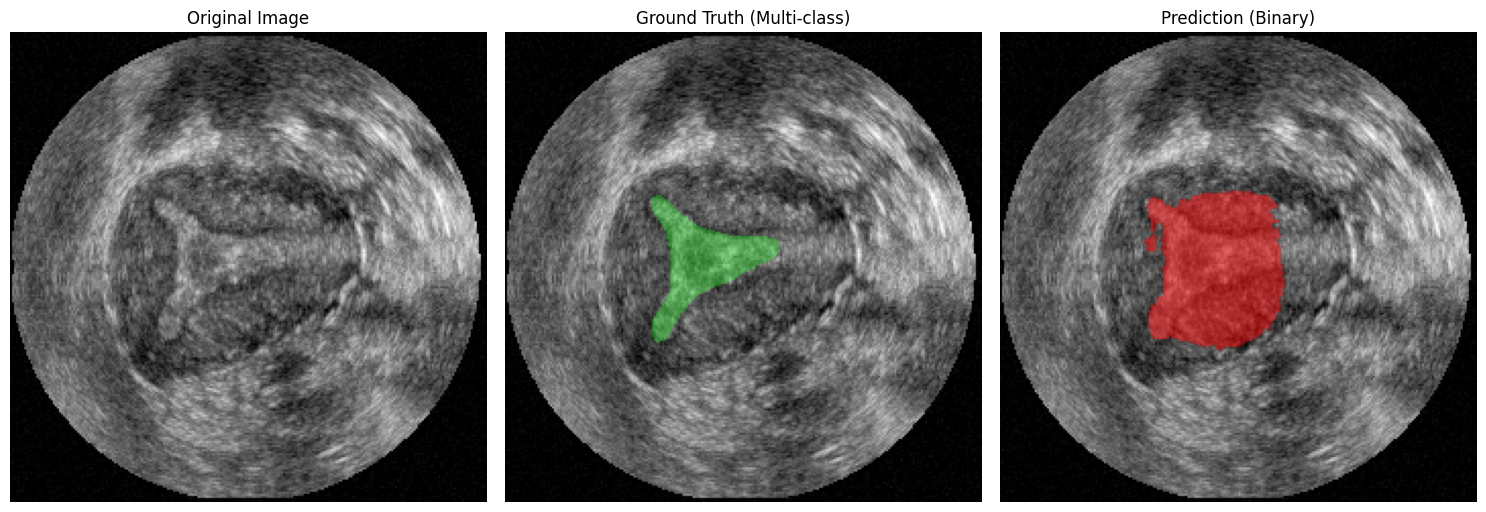


Generating additional visualizations...
Saved visualization for rank 1: 13_02.nii.gz
Saved visualization for rank 2: 22_33.nii.gz
Saved visualization for rank 3: 04_15.nii.gz
Saved visualization for rank 4: 04_08.nii.gz
Saved visualization for rank 5: 22_07.nii.gz

All results have been saved to Google Drive:
Main directory: /content/drive/MyDrive/SegTTA-SCI/results/UterUS/MedSAM2_results_MRI_LiverLesion_augmentation_noise_0823

各类别性能分析:
类别 1:
  平均IoU: 0.8171
  平均Dice: 0.8956
  样本数: 141


In [ ]:
# ============================================
# Cell 6: Visualization of Sample Results (FIXED)
# ============================================
# Visualize a sample result
def to_scalar(x):
    """
    Uniformly convert a list, ndarray, or scalar to a single float.
    - If iterable, safely cast each element to float and return the mean.
    - If a string scalar, cast directly to float.
    """
    # Single string or number
    if isinstance(x, (str, bytes)):
        return float(x)

    # List, tuple, or ndarray
    if isinstance(x, (list, tuple, np.ndarray)):
        # Cast each element to float, then take the mean
        return float(np.mean([float(v) for v in x]))

    # Already a number
    return float(x)

if seg_info['image_name']:
    # Select the case with the best mDice score for visualization
    best_idx = np.argmax(seg_info['mDice'])
    best_image = seg_info['image_name'][best_idx]

    miou  = to_scalar(seg_info['mIoU'][best_idx])
    aiou  = to_scalar(seg_info['aIoU'][best_idx])
    mdice = to_scalar(seg_info['mDice'][best_idx])  # usually already a float, wrapped for safety
    adice = to_scalar(seg_info['aDice'][best_idx])

    print(f"mIoU: {miou:.4f}")
    print(f"aIoU: {aiou:.4f}")
    print(f"mDice: {mdice:.4f}")
    print(f"aDice: {adice:.4f}")

    # Load image, label, and prediction
    img_path = os.path.join(imgs_path, best_image)
    label_path = os.path.join(labels_path, best_image)  # adjust to match your naming convention
    pred_path = os.path.join(predictions_dir, best_image.replace('.nii.gz', '_pred.nii.gz'))

    nii_image = sitk.ReadImage(img_path)
    nii_image_data = sitk.GetArrayFromImage(nii_image)
    nii_label = sitk.ReadImage(label_path)
    nii_label_data = sitk.GetArrayFromImage(nii_label)

    # Merge class 2 into 1 for binary segmentation
    nii_label_data[nii_label_data == 2] = 1

    nii_pred = sitk.ReadImage(pred_path)
    nii_pred_data = sitk.GetArrayFromImage(nii_pred)

    # Find slice with maximum overlap
    overlap = np.logical_and(nii_label_data > 0, nii_pred_data > 0)
    overlap_per_slice = np.sum(overlap, axis=(1, 2))
    key_slice = np.argmax(overlap_per_slice)

    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Normalize image for display
    img_slice = nii_image_data[key_slice]
    img_slice = (img_slice - np.min(img_slice)) / (np.max(img_slice) - np.min(img_slice))

    # Original image
    axes[0].imshow(img_slice, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Ground truth (display multi-class labels)
    axes[1].imshow(img_slice, cmap='gray')
    # Use different colors for different vascular classes
    unique_labels = np.unique(nii_label_data[key_slice])
    unique_labels = unique_labels[unique_labels > 0]
    for label_val in unique_labels:
        # Use different colors for different classes
        if label_val == 1:
            color = np.array([0, 1, 0])  # green
        elif label_val == 2:
            color = np.array([0, 0, 1])  # blue
        else:
            color = np.array([1, 1, 0])  # yellow
        show_mask(nii_label_data[key_slice] == label_val, axes[1], mask_color=color, alpha=0.3)
    axes[1].set_title('Ground Truth (Multi-class)')
    axes[1].axis('off')

    # Prediction
    axes[2].imshow(img_slice, cmap='gray')
    show_mask(nii_pred_data[key_slice] > 0, axes[2], mask_color=np.array([1, 0, 0]))
    axes[2].set_title('Prediction (Binary)')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(visualizations_dir, 'best_result_visualization.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Extra: save additional visualizations (top 5 best cases)
    print("\nGenerating additional visualizations...")
    top5_indices = np.argsort(seg_info['mDice'])[-5:][::-1]  # sorted by mDice

    for rank, idx in enumerate(top5_indices):
        case_name = seg_info['image_name'][idx]
        case_miou = seg_info['mIoU'][idx]
        case_aiou = seg_info['aIoU'][idx]
        case_mdice = seg_info['mDice'][idx]
        case_adice = seg_info['aDice'][idx]

        # Load data
        img_path = os.path.join(imgs_path, case_name)
        label_path = os.path.join(labels_path, case_name)
        pred_path = os.path.join(predictions_dir, case_name.replace('.nii.gz', '_pred.nii.gz'))

        try:
            nii_image = sitk.ReadImage(img_path)
            nii_image_data = sitk.GetArrayFromImage(nii_image)
            nii_label = sitk.ReadImage(label_path)
            nii_label_data = sitk.GetArrayFromImage(nii_label)

            # Merge class 2 into 1 for binary segmentation
            nii_label_data[nii_label_data == 2] = 1

            nii_pred = sitk.ReadImage(pred_path)
            nii_pred_data = sitk.GetArrayFromImage(nii_pred)

            # Find the slice with maximum overlap
            overlap = np.logical_and(nii_label_data > 0, nii_pred_data > 0)
            overlap_per_slice = np.sum(overlap, axis=(1, 2))
            if overlap_per_slice.sum() > 0:
                key_slice = np.argmax(overlap_per_slice)
            else:
                # No overlap: fall back to the slice with the largest label area
                label_per_slice = np.sum(nii_label_data > 0, axis=(1, 2))
                key_slice = np.argmax(label_per_slice)

            # Create visualization
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))

            # Normalize image
            img_slice = nii_image_data[key_slice]
            img_slice = (img_slice - np.min(img_slice)) / (np.max(img_slice) - np.min(img_slice) + 1e-8)

            # Show image and results
            axes[0].imshow(img_slice, cmap='gray')
            axes[0].set_title('Original')
            axes[0].axis('off')

            axes[1].imshow(img_slice, cmap='gray')
            # Show multi-class GT
            unique_labels = np.unique(nii_label_data[key_slice])
            unique_labels = unique_labels[unique_labels > 0]
            for label_val in unique_labels:
                if label_val == 1:
                    color = np.array([0, 1, 0])
                elif label_val == 2:
                    color = np.array([0, 0, 1])
                else:
                    color = np.array([1, 1, 0])
                show_mask(nii_label_data[key_slice] == label_val, axes[1], mask_color=color, alpha=0.3)
            axes[1].set_title('Ground Truth')
            axes[1].axis('off')

            axes[2].imshow(img_slice, cmap='gray')
            show_mask(nii_pred_data[key_slice] > 0, axes[2], mask_color=np.array([1, 0, 0]))
            axes[2].set_title('Prediction')
            axes[2].axis('off')

            plt.suptitle(f'Rank {rank+1}: {case_name} (mIoU={case_miou:.3f}, mDice={case_mdice:.3f})')
            plt.tight_layout()

            # Save to the visualizations folder
            save_name = f'top{rank+1}_result_{case_name.replace(".nii.gz", ".png")}'
            plt.savefig(os.path.join(visualizations_dir, save_name), dpi=150, bbox_inches='tight')
            plt.close()

            print(f"Saved visualization for rank {rank+1}: {case_name}")

        except Exception as e:
            print(f"Error visualizing {case_name}: {str(e)}")
            continue

    print(f"\nAll results have been saved to Google Drive:")
    print(f"Main directory: {pred_save_dir}")

    # Generate a detailed per-class performance report
    if 'per_class_iou' in all_metrics[0]:
        print("\nPer-class performance analysis:")
        print("="*50)

        # Collect all classes
        all_classes = set()
        for m in all_metrics:
            if 'per_class_iou' in m:
                all_classes.update(m['per_class_iou'].keys())

        # Compute average performance for each class
        for class_id in sorted(all_classes):
            class_ious = []
            class_dices = []
            for m in all_metrics:
                if 'per_class_iou' in m and class_id in m['per_class_iou']:
                    class_ious.append(m['per_class_iou'][class_id])
                    class_dices.append(m['per_class_dice'][class_id])

            if class_ious:
                print(f"Class {class_id}:")
                print(f"  Mean IoU: {np.mean(class_ious):.4f}")
                print(f"  Mean Dice: {np.mean(class_dices):.4f}")
                print(f"  Sample count: {len(class_ious)}")

## 7 - Image Augmentation Pipeline

**Purpose:** Generate augmented medical images to test model robustness using four different augmentation techniques.

**Augmentation Methods:**

1. **Gamma Correction (γ: 0.8-1.2)**
  - Nonlinear brightness adjustment affecting global illumination
  - Maintains original data range while adjusting contrast
  - Simulates varying imaging conditions

2. **Contrast Enhancement (α: 1.1-1.3)**
  - Linear grayscale stretching to expand tissue contrast
  - Centers adjustment around mean intensity
  - Enhances boundary visibility between structures

3. **Gaussian Blur (σ: 0.5-1.5)**
  - Spatial smoothing to simulate resolution variations
  - 3D filtering with edge preservation
  - Tests model's response to reduced image sharpness

4. **Gaussian Noise (5-10% of image std)**
  - Additive random perturbations simulating scanner artifacts
  - Maintains original intensity range through clipping
  - Evaluates robustness to noisy acquisition conditions

**Implementation Features:**
- Random parameter selection within specified ranges for each image
- Preserves NIfTI header information and spatial orientation
- Generates detailed JSON records tracking augmentation parameters
- Calculates quality metrics (SNR reduction, edge strength, enhancement ratios)

**Output Structure:**
- Separate folders for each augmentation type
- Augmented images maintain original filenames for easy matching
- Comprehensive statistics including parameter distributions and effect measurements
- JSON records for reproducibility and analysis

**Usage:** Cell 7.1 applies all four augmentations to the complete dataset, creating test sets for evaluating model generalization under various imaging conditions.

In [ ]:
# ============================================
# Cell 7: Image augmentation
# ============================================

# Gamma Correction
# Adjusts the global brightness curve (nonlinear transform), affecting overall image luminance
# (e.g., brightening dark lesion regions or darkening overexposed areas).
# Gamma randomly sampled from 0.8-1.2 (mild adjustment, original brightness distribution preserved).

# Image augmentation Dependency
!pip install nibabel

import os
import numpy as np
import nibabel as nib
from glob import glob
import json
def gamma_correction(image: np.ndarray, gamma: float) -> np.ndarray:
    """
    Apply gamma correction while preserving the original data range.
    """
    image = image.astype(np.float32)
    image_min, image_max = image.min(), image.max()

    if image_max > image_min:
        normalized = (image - image_min) / (image_max - image_min)
        corrected = np.power(normalized, gamma)
        corrected = corrected * (image_max - image_min) + image_min
        return corrected
    else:
        return image

def apply_random_gamma_tta(input_folder: str, output_folder: str,
                          gamma_range: tuple = (0.8, 1.2),
                          seed: int = None) -> dict:
    """
    Apply random gamma correction to each image for augmentation.

    Args:
        input_folder: Path to the input folder
        output_folder: Path to the output folder
        gamma_range: Range for random gamma values
        seed: Random seed (optional)

    Returns:
        gamma_record: Dictionary recording the gamma value applied to each image
    """
    os.makedirs(output_folder, exist_ok=True)

    # Set random seed (if provided)
    if seed is not None:
        np.random.seed(seed)

    # Get all image files
    nii_files = sorted(glob(os.path.join(input_folder, '*.nii.gz')))

    print(f"Found {len(nii_files)} image files")
    print(f"Gamma range: {gamma_range}")

    # Record the gamma value used for each file
    gamma_record = {}

    for file_path in nii_files:
        # Load image
        img_obj = nib.load(file_path)
        img_data = img_obj.get_fdata()
        affine = img_obj.affine
        header = img_obj.header

        base_filename = os.path.basename(file_path).replace('.nii.gz', '')

        # Sample a random gamma value
        gamma = round(np.random.uniform(gamma_range[0], gamma_range[1]), 2)

        # Apply gamma correction
        corrected = gamma_correction(img_data, gamma)

        # Save augmented image
        # out_filename = f"{base_filename}_gamma{gamma:.2f}.nii.gz"
        out_filename = f"{base_filename}.nii.gz"
        out_path = os.path.join(output_folder, out_filename)

        out_nifti = nib.Nifti1Image(corrected, affine=affine, header=header)
        nib.save(out_nifti, out_path)

        # Record gamma value
        gamma_record[base_filename] = {
            'original_file': file_path,
            'output_file': out_filename,
            'gamma': gamma
        }

        print(f"Processing: {base_filename} -> gamma={gamma}")

    # Save gamma record
    record_path = os.path.join(output_folder, 'gamma_record.json')
    with open(record_path, 'w') as f:
        json.dump(gamma_record, f, indent=2)

    print(f"\nDone!")
    print(f"Results saved to: {output_folder}")
    print(f"Gamma record saved to: {record_path}")

    # Print gamma value statistics
    all_gammas = [info['gamma'] for info in gamma_record.values()]
    print(f"\nGamma value statistics:")
    print(f"  Mean: {np.mean(all_gammas):.3f}")
    print(f"  Std:  {np.std(all_gammas):.3f}")
    print(f"  Min:  {min(all_gammas)}")
    print(f"  Max:  {max(all_gammas)}")

    return gamma_record

# Contrast Enhancement
# Stretches the grayscale range (linear transform) to amplify the intensity difference between
# lesion and normal tissue, enhancing boundary visibility (may also amplify noise).
# Scaling factor alpha randomly sampled from 1.1-1.3 (moderate enhancement, no pixel saturation).
import os
import numpy as np
import nibabel as nib
from glob import glob
import json

def contrast_enhancement(image, alpha):
    """
    Contrast enhancement: linearly scale the intensity range.

    Args:
        image: Input image
        alpha: Contrast scaling factor (>1 increases contrast)

    Returns:
        Enhanced image
    """
    image = image.astype(np.float32)
    image_min, image_max = image.min(), image.max()

    # Use mean as the center point for contrast adjustment
    mean_val = np.mean(image)

    # Apply contrast enhancement
    enhanced = (image - mean_val) * alpha + mean_val

    # Clip to the original range to prevent saturation
    enhanced = np.clip(enhanced, image_min, image_max)

    return enhanced

def apply_contrast_enhancement(input_folder, output_folder, alpha_range=(1.1, 1.3), seed=None):
    """
    Apply random contrast enhancement to each image.

    Args:
        input_folder: Path to the input folder
        output_folder: Path to the output folder
        alpha_range: Range for random alpha values
        seed: Random seed
    """
    os.makedirs(output_folder, exist_ok=True)

    if seed is not None:
        np.random.seed(seed)

    # Get all image files
    nii_files = sorted(glob(os.path.join(input_folder, '*.nii.gz')))

    print(f"Found {len(nii_files)} image files")
    print(f"Alpha range: {alpha_range}")

    contrast_record = {}

    for file_path in nii_files:
        # Load image
        img_obj = nib.load(file_path)
        img_data = img_obj.get_fdata()
        affine = img_obj.affine
        header = img_obj.header

        # Get filename
        filename = os.path.basename(file_path)
        base_filename = filename.replace('.nii.gz', '')

        # Sample a random alpha value
        alpha = round(np.random.uniform(alpha_range[0], alpha_range[1]), 2)

        # Apply contrast enhancement
        enhanced = contrast_enhancement(img_data, alpha)

        # Check enhancement effect
        original_std = np.std(img_data)
        enhanced_std = np.std(enhanced)
        actual_enhancement = (enhanced_std / original_std - 1) * 100

        # Save the enhanced image
        # out_filename = f"{base_filename}_contrast{alpha:.2f}.nii.gz"
        out_filename = f"{base_filename}.nii.gz"
        out_path = os.path.join(output_folder, out_filename)

        out_nifti = nib.Nifti1Image(enhanced, affine=affine, header=header)
        nib.save(out_nifti, out_path)

        # Record information
        contrast_record[base_filename] = {
            'original_file': filename,
            'output_file': out_filename,
            'alpha': alpha,
            'actual_enhancement': f"{actual_enhancement:.1f}%"
        }

        print(f"Processing: {base_filename} -> alpha={alpha}, actual enhancement={actual_enhancement:.1f}%")

    # Save record
    record_path = os.path.join(output_folder, 'contrast_record.json')
    with open(record_path, 'w') as f:
        json.dump(contrast_record, f, indent=2)

    print(f"\nContrast enhancement complete!")
    print(f"Results saved to: {output_folder}")
    print(f"Contrast record: {record_path}")

    # Statistics
    all_alphas = [info['alpha'] for info in contrast_record.values()]
    print(f"\nAlpha value statistics:")
    print(f"  Mean: {np.mean(all_alphas):.3f}")
    print(f"  Std:  {np.std(all_alphas):.3f}")
    print(f"  Min:  {min(all_alphas)}")
    print(f"  Max:  {max(all_alphas)}")

    return contrast_record

# Gaussian Blur
# Smooths image details (spatial-domain filtering), primarily attenuating high-frequency content
# (e.g., lesion boundary sharpness) to simulate lower-resolution acquisition.
# Sigma randomly sampled from 0.5-1.5 (mild smoothing, lesion structure preserved).
import os
import numpy as np
import nibabel as nib
from glob import glob
import json
from scipy.ndimage import gaussian_filter

def gaussian_blur_3d(image, sigma):
    """
    3D Gaussian blur tailored for medical images.

    Args:
        image: 3D medical image volume
        sigma: Standard deviation of the Gaussian kernel (scalar or 3-tuple)

    Returns:
        Blurred image
    """
    image = image.astype(np.float32)

    # If sigma is a scalar, it is applied uniformly to all dimensions;
    # if a tuple, each element is applied to the corresponding dimension.
    blurred = gaussian_filter(image, sigma=sigma, mode='reflect')

    return blurred

def apply_gaussian_blur(input_folder, output_folder,
                                  sigma_range=(0.5, 1.5), seed=None):
    """
    Apply random Gaussian blur to each image (simplified version).

    Args:
        input_folder: Path to the input folder
        output_folder: Path to the output folder
        sigma_range: Range for random sigma values
        seed: Random seed
    """
    os.makedirs(output_folder, exist_ok=True)

    if seed is not None:
        np.random.seed(seed)

    # Get all image files
    nii_files = sorted(glob(os.path.join(input_folder, '*.nii.gz')))

    print(f"Found {len(nii_files)} image files")
    print(f"Sigma range: {sigma_range}")

    blur_record = {}

    for file_path in nii_files:
        # Load image
        img_obj = nib.load(file_path)
        img_data = img_obj.get_fdata()
        affine = img_obj.affine
        header = img_obj.header

        # Get filename
        filename = os.path.basename(file_path)
        base_filename = filename.replace('.nii.gz', '')

        # Sample a random sigma value
        sigma = round(np.random.uniform(sigma_range[0], sigma_range[1]), 2)

        # Apply Gaussian blur
        blurred = gaussian_blur_3d(img_data, sigma)

        # Measure blurring effect (reduction in edge intensity)
        original_edges = np.std(np.gradient(img_data, axis=0))
        blurred_edges = np.std(np.gradient(blurred, axis=0))
        edge_reduction = (1 - blurred_edges / original_edges) * 100

        # Save the blurred image
        # out_filename = f"{base_filename}_blur{sigma:.2f}.nii.gz"
        out_filename = f"{base_filename}.nii.gz"
        out_path = os.path.join(output_folder, out_filename)

        out_nifti = nib.Nifti1Image(blurred, affine=affine, header=header)
        nib.save(out_nifti, out_path)

        # Record information
        blur_record[base_filename] = {
            'original_file': filename,
            'output_file': out_filename,
            'sigma': sigma,
            'edge_reduction': f"{edge_reduction:.1f}%",
            'image_shape': img_data.shape
        }

        print(f"Processing: {base_filename} -> sigma={sigma}, edge reduction={edge_reduction:.1f}%")

    # Save record
    record_path = os.path.join(output_folder, 'blur_record.json')
    with open(record_path, 'w') as f:
        json.dump(blur_record, f, indent=2)

    print(f"\nGaussian blur complete!")
    print(f"Results saved to: {output_folder}")
    print(f"Blur record: {record_path}")

    # Statistics
    all_sigmas = [info['sigma'] for info in blur_record.values()]
    print(f"\nSigma value statistics:")
    print(f"  Mean: {np.mean(all_sigmas):.3f}")
    print(f"  Std:  {np.std(all_sigmas):.3f}")
    print(f"  Min:  {min(all_sigmas)}")
    print(f"  Max:  {max(all_sigmas)}")

    return blur_record

def apply_gaussian_blur_tta(input_folder, output_folder,
                          sigma_values=None, seed=42):
    """
    TTA-based Gaussian blur augmentation (full version).

    Args:
        input_folder: Input folder path
        output_folder: Output folder path
        sigma_values: Fixed list of sigma values to apply
        seed: Random seed
    """
    os.makedirs(output_folder, exist_ok=True)

    # Use a fixed set of sigma values (including identity transform, sigma=0)
    if sigma_values is None:
        sigma_values = [0.0, 0.5, 0.75, 1.0, 1.25, 1.5]  # includes 0 (no blur, identity transform)

    # Get file list
    image_files = sorted(glob(os.path.join(input_folder, '*.nii.gz')))

    print(f"Found {len(image_files)} image files")
    print(f"Using sigma values: {sigma_values}")

    # Compute theoretical weights
    weights = calculate_blur_weights(sigma_values)

    arg_info = {
        'augmentation_type': 'gaussian_blur',
        'sigma_values': sigma_values,
        'theoretical_weights': weights.tolist(),
        'processed_files': {}
    }

    for image_path in image_files:
        filename = os.path.basename(image_path)
        base_name = filename.replace('.nii.gz', '')

        # Load image
        img_obj = nib.load(image_path)
        img_data = img_obj.get_fdata()

        augmented_files = []

        for i, sigma in enumerate(sigma_values):
            # Apply Gaussian blur
            if sigma == 0:
                blurred = img_data  # identity transform (no blur)
            else:
                blurred = gaussian_blur_3d(img_data, sigma)

            # Save
            out_filename = f"{base_name}_blur{sigma:.1f}.nii.gz"
            out_path = os.path.join(output_folder, out_filename)

            out_nifti = nib.Nifti1Image(blurred, affine=img_obj.affine,
                                       header=img_obj.header)
            nib.save(out_nifti, out_path)

            augmented_files.append({
                'filename': out_filename,
                'sigma': sigma,
                'weight': weights[i]
            })

        arg_info['processed_files'][base_name] = {
            'original_file': filename,
            'augmented_files': augmented_files
        }

        print(f"Processing: {filename} -> generating {len(sigma_values)} blurred versions")

    # Save augmentation info
    info_path = os.path.join(output_folder, 'gaussian_blur_info.json')
    with open(info_path, 'w') as f:
        json.dump(arg_info, f, indent=2)

    print(f"\nDone!")
    print(f"Theoretical weights: {weights}")

    return arg_info

def calculate_blur_weights(sigma_values):
    """
    Compute theoretical weights for Gaussian blur augmentation.
    No-blur (sigma=0) has the highest weight; higher blur levels receive lower weights.
    """
    sigma_array = np.array(sigma_values)

    # Weights are inversely proportional to sigma (less blur -> higher weight)
    weights = 1.0 / (1.0 + sigma_array)

    # Normalize
    weights = weights / weights.sum()

    return weights


# Gaussian Noise Injection
# Adds random pixel perturbations (additive noise) to simulate scanner noise or acquisition artifacts,
# testing the model's robustness to noisy inputs.
# Noise std set to 5%-10% of the image std (subtle noise, lesion visibility preserved).
import os
import numpy as np
import nibabel as nib
from glob import glob
import json

def add_gaussian_noise(image, noise_ratio, seed=None):
    """
    Add Gaussian noise to an image.

    Args:
        image: Input image
        noise_ratio: Noise level relative to the image standard deviation
        seed: Random seed for reproducibility

    Returns:
        Noisy image
    """
    image = image.astype(np.float32)
    image_min, image_max = image.min(), image.max()

    # Set random seed
    if seed is not None:
        rng = np.random.RandomState(seed)
    else:
        rng = np.random.RandomState()

    # Compute noise standard deviation
    image_std = np.std(image)
    noise_std = image_std * noise_ratio

    # Generate Gaussian noise
    noise = rng.normal(0, noise_std, image.shape)

    # Add noise
    noisy_image = image + noise

    # Clip to the original range
    noisy_image = np.clip(noisy_image, image_min, image_max)

    return noisy_image

def apply_gaussian_noise(input_folder, output_folder,
                                   ratio_range=(0.05, 0.1), seed=None):
    """
    Apply Gaussian noise augmentation to each image.

    Args:
        input_folder: Path to the input folder
        output_folder: Path to the output folder
        ratio_range: Range of noise ratio values
        seed: Master random seed
    """
    os.makedirs(output_folder, exist_ok=True)

    if seed is not None:
        np.random.seed(seed)

    # Get all image files
    nii_files = sorted(glob(os.path.join(input_folder, '*.nii.gz')))

    print(f"Found {len(nii_files)} image files")
    print(f"Noise type: Gaussian (100%)")
    print(f"Noise ratio range: {ratio_range}")

    noise_record = {}

    for idx, file_path in enumerate(nii_files):
        # Load image
        img_obj = nib.load(file_path)
        img_data = img_obj.get_fdata()
        affine = img_obj.affine
        header = img_obj.header

        # Get filename
        filename = os.path.basename(file_path)
        base_filename = filename.replace('.nii.gz', '')

        # Sample a random noise ratio
        noise_ratio = round(np.random.uniform(ratio_range[0], ratio_range[1]), 3)

        # Generate a unique seed for each image
        image_seed = seed + idx if seed is not None else None

        # Apply Gaussian noise
        noisy_image = add_gaussian_noise(img_data, noise_ratio, seed=image_seed)

        # Compute SNR change
        original_mean = np.mean(img_data)
        original_std = np.std(img_data)
        noisy_mean = np.mean(noisy_image)
        noisy_std = np.std(noisy_image)

        original_snr = original_mean / original_std if original_std > 0 else 0
        noisy_snr = noisy_mean / noisy_std if noisy_std > 0 else 0
        snr_reduction = (1 - noisy_snr / original_snr) * 100 if original_snr > 0 else 0

        # Save the noisy image
        # out_filename = f"{base_filename}_noise{int(noise_ratio*1000):03d}.nii.gz"
        out_filename = f"{base_filename}.nii.gz"
        out_path = os.path.join(output_folder, out_filename)

        out_nifti = nib.Nifti1Image(noisy_image, affine=affine, header=header)
        nib.save(out_nifti, out_path)

        # Record information
        noise_record[base_filename] = {
            'original_file': filename,
            'output_file': out_filename,
            'noise_ratio': noise_ratio,
            'noise_percentage': f"{noise_ratio*100:.1f}%",
            'noise_type': 'gaussian',
            'snr_reduction': f"{snr_reduction:.1f}%",
            'seed': image_seed
        }

        print(f"Processing: {base_filename} -> noise ratio={noise_ratio:.3f} ({noise_ratio*100:.1f}%), SNR reduction={snr_reduction:.1f}%")

    # Save record
    record_path = os.path.join(output_folder, 'gaussian_noise_record.json')
    with open(record_path, 'w') as f:
        json.dump(noise_record, f, indent=2)

    print(f"\nGaussian noise injection complete!")
    print(f"Results saved to: {output_folder}")
    print(f"Noise record: {record_path}")

    # Statistics
    all_ratios = [info['noise_ratio'] for info in noise_record.values()]
    print(f"\nNoise ratio statistics:")
    print(f"  Mean: {np.mean(all_ratios):.3f} ({np.mean(all_ratios)*100:.1f}%)")
    print(f"  Std:  {np.std(all_ratios):.3f}")
    print(f"  Min:  {min(all_ratios):.3f} ({min(all_ratios)*100:.1f}%)")
    print(f"  Max:  {max(all_ratios):.3f} ({max(all_ratios)*100:.1f}%)")

    # Analyze noise effect
    snr_reductions = []
    for info in noise_record.values():
        snr_red = float(info['snr_reduction'].replace('%', ''))
        snr_reductions.append(snr_red)

    print(f"\nSNR reduction statistics:")
    print(f"  Mean SNR reduction: {np.mean(snr_reductions):.1f}%")
    print(f"  Max SNR reduction: {max(snr_reductions):.1f}%")
    print(f"  Min SNR reduction: {min(snr_reductions):.1f}%")

    return noise_record


In [ ]:
# ============================================
# Cell 7.1: Apply Image augmentation
# ============================================
# Import necessary modules
from datetime import datetime
import os

timestamp = datetime.now().strftime("%m%d")

dataset_path = '/content/drive/MyDrive/SegTTA-SCI/dataset/UterUS/dataset'
input_folder = os.path.join(dataset_path, 'annotated_volumes')
result_path = '/content/drive/MyDrive/SegTTA-SCI/results/UterUS'


# Gamma correction
output_folder = os.path.join(result_path, f'augmentation_gamma_correction_{timestamp}')
gamma_record = apply_random_gamma_tta(
  input_folder=input_folder,
  output_folder=output_folder,
  gamma_range=(0.8, 1.2),
  seed=None
)

# Contrast enhancement
output_folder = os.path.join(result_path, f'augmentation_contrast_enhancement_{timestamp}')
contrast_record = apply_contrast_enhancement(
  input_folder=input_folder,
  output_folder=output_folder,
  alpha_range=(1.1, 1.3),
  seed=None
)

# Gaussian blur
output_folder = os.path.join(result_path, f'augmentation_gaussian_blur_{timestamp}')
blur_record = apply_gaussian_blur(
  input_folder=input_folder,
  output_folder=output_folder,
  sigma_range=(0.5, 1.5),
  seed=None
)

# Gaussian noise
output_folder = os.path.join(result_path, f'augmentation_noise_{timestamp}')
noise_record = apply_gaussian_noise(
  input_folder=input_folder,
  output_folder=output_folder,
  ratio_range=(0.05, 0.1),
  seed=None
)

找到 141 个图像文件
Gamma范围: (0.8, 1.2)
处理: 04_01 -> gamma=1.1
处理: 04_02 -> gamma=0.9
处理: 04_03 -> gamma=0.98
处理: 04_04 -> gamma=1.15
处理: 04_05 -> gamma=0.92
处理: 04_06 -> gamma=1.11
处理: 04_07 -> gamma=1.1
处理: 04_08 -> gamma=0.97
处理: 04_09 -> gamma=0.89
处理: 04_10 -> gamma=0.97
处理: 04_11 -> gamma=0.83
处理: 04_12 -> gamma=1.04
处理: 04_13 -> gamma=1.13
处理: 04_14 -> gamma=1.16
处理: 04_15 -> gamma=0.88
处理: 04_16 -> gamma=1.0
处理: 04_17 -> gamma=1.16
处理: 04_18 -> gamma=0.9
处理: 04_19 -> gamma=1.15
处理: 04_20 -> gamma=0.81
处理: 04_21 -> gamma=1.02
处理: 04_22 -> gamma=1.01
处理: 04_23 -> gamma=1.17
处理: 04_24 -> gamma=0.9
处理: 04_25 -> gamma=0.83
处理: 04_26 -> gamma=1.16
处理: 04_28 -> gamma=1.15
处理: 04_29 -> gamma=0.87
处理: 04_30 -> gamma=1.2
处理: 04_31 -> gamma=0.94
处理: 04_32 -> gamma=0.93
处理: 04_34 -> gamma=1.14
处理: 04_35 -> gamma=1.15
处理: 04_39 -> gamma=1.07
处理: 04_40 -> gamma=0.82
处理: 04_41 -> gamma=1.02
处理: 04_42 -> gamma=1.08
处理: 04_43 -> gamma=1.13
处理: 04_44 -> gamma=0.92
处理: 04_46 -> gamma=1.0
处理: 04_47 -> ga

## 8 - Voting-Based Fusion for Test-Time Augmentation

**Purpose:** Combine predictions from multiple augmented versions of images using voting strategies to improve segmentation robustness.

**Core Components:**

1. **Prediction Loading:**
  - Loads segmentation masks from 4 augmentation methods (gamma correction, contrast enhancement, Gaussian blur, noise injection)
  - Handles optional confidence maps for weighted fusion
  - Maintains spatial alignment across all predictions

2. **Fusion Methods:**
  - **Soft Voting:** Simple averaging of all predictions
  - **Weighted Voting:** Assigns different weights to augmentations based on expected performance (weights: [0.4, 0.4, 0.6, 0.6])
  - **Threshold Voting:** Calculates voting ratios for each pixel

3. **Confidence Map Generation:**
  - Produces continuous confidence values (0-1 range)
  - Shows prediction agreement across augmentations
  - Enables flexible threshold selection (typically 0.6 for optimal results)

4. **Threshold Application:**
  - Converts confidence maps to binary masks
  - Tracks foreground pixel statistics and voting distributions
  - Outputs pixel-level agreement patterns

**Output Structure:**
- **Fused confidence maps:** Continuous values showing prediction certainty
- **Binary masks:** Final segmentation results after thresholding
- **Statistical reports:** JSON summaries, CSV statistics, detailed text reports
- **Pickle files:** Complete results for further analysis
- **Timestamped directories:** Organized results by voting method and threshold

**Key Features:**
- Processes predictions from best-performing checkpoint across all augmentations
- Voting distribution analysis showing pixel-level agreement patterns
- Comprehensive statistics including confidence distributions and foreground percentages
- Preserves original image metadata (spacing, orientation) in outputs

**Workflow:** Combines predictions from 4 augmentation methods using weighted voting strategy, generates confidence-based final segmentations with detailed performance tracking and statistical analysis.

In [ ]:
# ============================================
# Cell 8: Voting (corrected version)
# ============================================
import numpy as np
import SimpleITK as sitk
from glob import glob
import os
import json
import pickle
from datetime import datetime
import pandas as pd

def load_predictions_with_confidence(pred_dirs, image_name):
    """
    Load predictions and confidence maps from all augmentation versions.

    Args:
        pred_dirs: List of prediction result folders (one per augmentation)
        image_name: Original image filename

    Returns:
        predictions: List of binary mask arrays
        confidences: List of confidence map arrays
    """
    predictions = []
    confidences = []

    for pred_dir in pred_dirs:
        # Assumed prediction file naming convention
        pred_path = os.path.join(pred_dir, 'predictions', f'{image_name.replace(".nii.gz", "_pred.nii.gz")}')

        # Load prediction mask
        pred_img = sitk.ReadImage(pred_path)
        pred_data = sitk.GetArrayFromImage(pred_img)
        predictions.append(pred_data)

        # Load confidence map if available
        conf_path = pred_path.replace('_pred.nii.gz', '_conf.nii.gz')
        if os.path.exists(conf_path):
            conf_img = sitk.ReadImage(conf_path)
            conf_data = sitk.GetArrayFromImage(conf_img)
        else:
            # Fall back to using the binary mask as confidence (0 or 1)
            conf_data = pred_data.astype(float)

        confidences.append(conf_data)

    return predictions, confidences

def enhanced_voting_fusion(predictions, confidences=None, voting_method='soft_voting'):
    """
    Enhanced voting fusion method.

    Args:
        predictions: List of binary masks with shape (n_models, D, H, W)
        confidences: List of confidence maps (optional)
        voting_method: Fusion/voting method to use

    Returns:
        fused_confidence: Fused confidence map (range [0, 1])
    """
    predictions = np.array(predictions)
    n_models = predictions.shape[0]

    if voting_method == 'soft_voting':
        # Soft voting: simple average, yielding values 0, 0.25, 0.5, 0.75, 1.0
        fused_confidence = np.mean(predictions, axis=0)

    elif voting_method == 'weighted_voting':
        # Weighted voting: assign different weights to different augmentation methods
        # Example: give higher-performing augmentations higher weights
        weights = np.array([0.4, 0.4, 0.6, 0.6])
        weights = weights / weights.sum()

        weighted_sum = np.zeros_like(predictions[0], dtype=float)
        for i, (pred, w) in enumerate(zip(predictions, weights)):
            weighted_sum += pred * w
        fused_confidence = weighted_sum

    elif voting_method == 'threshold_voting':
        # Threshold voting: compute the vote fraction
        vote_count = np.sum(predictions, axis=0)
        fused_confidence = vote_count / n_models
    else:
        # Default: soft voting
        fused_confidence = np.mean(predictions, axis=0)

    # Verify output range
    print(f"Fused confidence range: [{fused_confidence.min():.3f}, {fused_confidence.max():.3f}]")
    unique_values = np.unique(fused_confidence)
    if len(unique_values) < 10:
        print(f"Unique values: {unique_values}")

    return fused_confidence

def apply_threshold(confidence_map, threshold=0.5):
    """
    Apply a threshold to produce a binary mask.

    Args:
        confidence_map: Confidence map
        threshold: Binarization threshold

    Returns:
        binary_mask: Binary segmentation result
    """
    return (confidence_map >= threshold).astype(np.uint8)

def save_fusion_results(fusion_results, output_dir, augmentation_names, voting_method, threshold):
    """
    Save fusion results in multiple file formats.

    Args:
        fusion_results: List of fusion result dicts
        output_dir: Output directory
        augmentation_names: Names of the augmentation methods used
        voting_method: Voting/fusion method
        threshold: Threshold applied to the confidence map
    """
    # Create results directory
    results_dir = os.path.join(output_dir, 'fusion_results')
    os.makedirs(results_dir, exist_ok=True)

    # 1. Save summary statistics to JSON
    summary = {
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'num_images': len(fusion_results),
        'augmentation_methods': augmentation_names,
        'voting_method': voting_method,
        'threshold': threshold,
        'images_processed': [r['image'] for r in fusion_results]
    }

    # Compute confidence statistics
    confidence_stats = []
    for result in fusion_results:
        conf_map = result['fused_confidence']
        final_mask = result['final_mask']

        stats = {
            'image': result['image'],
            'confidence_mean': float(np.mean(conf_map)),
            'confidence_std': float(np.std(conf_map)),
            'confidence_min': float(np.min(conf_map)),
            'confidence_max': float(np.max(conf_map)),
            'foreground_pixels': int(np.sum(final_mask)),
            'foreground_percentage': float(np.sum(final_mask) / final_mask.size * 100)
        }
        confidence_stats.append(stats)

    summary['confidence_statistics'] = confidence_stats

    # Save JSON
    json_path = os.path.join(results_dir, f'fusion_summary_threshold_{threshold:.2f}.json')
    with open(json_path, 'w') as f:
        json.dump(summary, f, indent=4)

    # 2. Save detailed statistics to CSV
    df = pd.DataFrame(confidence_stats)
    csv_path = os.path.join(results_dir, f'fusion_statistics_threshold_{threshold:.2f}.csv')
    df.to_csv(csv_path, index=False)

    # 3. Save complete results to pickle (includes numpy arrays)
    pickle_path = os.path.join(results_dir, f'fusion_results_complete_threshold_{threshold:.2f}.pkl')
    # Save only essential info to keep file size manageable
    results_to_save = []
    for result in fusion_results:
        results_to_save.append({
            'image': result['image'],
            'confidence_map_shape': result['fused_confidence'].shape,
            'final_mask_shape': result['final_mask'].shape,
            # Full arrays can optionally be saved here
            # 'fused_confidence': result['fused_confidence'],
            # 'final_mask': result['final_mask']
        })

    with open(pickle_path, 'wb') as f:
        pickle.dump({
            'summary': summary,
            'results': results_to_save,
            'full_results_available': False  # indicates whether full arrays are stored
        }, f)

    # 4. Generate summary report
    report_path = os.path.join(results_dir, f'fusion_report_threshold_{threshold:.2f}.txt')
    with open(report_path, 'w') as f:
        f.write("TTA Fusion Results Report\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"Generated at: {summary['timestamp']}\n")
        f.write(f"Number of images processed: {summary['num_images']}\n")
        f.write(f"Augmentation methods: {', '.join(augmentation_names)}\n")
        f.write(f"Voting method: {voting_method}\n")
        f.write(f"Threshold: {threshold}\n\n")

        f.write("Confidence Statistics Summary:\n")
        f.write("-" * 40 + "\n")
        f.write(f"Average confidence mean: {df['confidence_mean'].mean():.3f}\n")
        f.write(f"Average foreground percentage: {df['foreground_percentage'].mean():.1f}%\n")
        f.write(f"Min foreground pixels: {df['foreground_pixels'].min()}\n")
        f.write(f"Max foreground pixels: {df['foreground_pixels'].max()}\n\n")

        f.write("Per-image Results:\n")
        f.write("-" * 40 + "\n")
        for _, row in df.iterrows():
            f.write(f"{row['image']}: "
                   f"conf_mean={row['confidence_mean']:.3f}, "
                   f"foreground={row['foreground_percentage']:.1f}%\n")

    print(f"\nFusion results saved to:")
    print(f"  - Summary JSON: {json_path}")
    print(f"  - Statistics CSV: {csv_path}")
    print(f"  - Complete results: {pickle_path}")
    print(f"  - Report: {report_path}")

    return {
        'json_path': json_path,
        'csv_path': csv_path,
        'pickle_path': pickle_path,
        'report_path': report_path
    }

def tta_fusion_pipeline(image_files, augmentation_dirs, output_dir,
                       voting_method='weighted_average', threshold=0.5):
    """
    Complete TTA fusion pipeline.

    Args:
        image_files: List of original image files
        augmentation_dirs: Folders containing predictions for each augmentation
        output_dir: Output folder
        voting_method: Voting/fusion method
        threshold: Binarization threshold
    """
    os.makedirs(output_dir, exist_ok=True)

    # Create subfolders for each threshold value
    threshold_dir = os.path.join(output_dir, f'threshold_{threshold:.2f}')
    os.makedirs(threshold_dir, exist_ok=True)

    fusion_results = []

    # Extract augmentation method names from directory names
    augmentation_names = []
    for dir_path in augmentation_dirs:
        # Extract augmentation method name from directory name
        dir_name = os.path.basename(dir_path)
        if 'gamma' in dir_name:
            augmentation_names.append('gamma_correction')
        elif 'contrast' in dir_name:
            augmentation_names.append('contrast_enhancement')
        elif 'blur' in dir_name:
            augmentation_names.append('gaussian_blur')
        elif 'noise' in dir_name:
            augmentation_names.append('gaussian_noise')
        else:
            augmentation_names.append(dir_name)

    # Process each image
    for img_file in image_files:
        img_name = os.path.basename(img_file)

        # 1. Load predictions from all augmentation versions
        predictions, confidences = load_predictions_with_confidence(
            augmentation_dirs, img_name
        )

        # 2. Fuse predictions via confidence voting
        print(f"\nProcessing {img_name} - voting method: {voting_method}")
        fused_confidence = enhanced_voting_fusion(
            predictions, confidences, voting_method
        )

        # For threshold_voting, print the vote distribution
        if voting_method == 'threshold_voting':
            vote_count = np.sum(predictions, axis=0)
            print(f"Vote distribution:")
            for i in range(5):
                pixels = np.sum(vote_count == i)
                if pixels > 0:
                    print(f"  {i} votes: {pixels} pixels ({pixels/vote_count.size*100:.2f}%)")

        # 3. Apply threshold
        final_mask = apply_threshold(fused_confidence, threshold)
        print(f"After threshold {threshold}: foreground pixels = {np.sum(final_mask)} ({np.sum(final_mask)/final_mask.size*100:.2f}%)")

        # 4. Save results — fused confidence map
        conf_save_path = os.path.join(threshold_dir,
                                     img_name.replace('.nii.gz', '_fused_conf.nii.gz'))
        # Final binary mask
        mask_save_path = os.path.join(threshold_dir,
                                     img_name.replace('.nii.gz', '_fused_mask.nii.gz'))

        # Copy spatial metadata from the original image
        orig_img = sitk.ReadImage(img_file)

        conf_img = sitk.GetImageFromArray(fused_confidence)
        conf_img.CopyInformation(orig_img)
        sitk.WriteImage(conf_img, conf_save_path)

        mask_img = sitk.GetImageFromArray(final_mask)
        mask_img.CopyInformation(orig_img)
        sitk.WriteImage(mask_img, mask_save_path)

        fusion_results.append({
            'image': img_name,
            'fused_confidence': fused_confidence,
            'final_mask': final_mask
        })

        print(f"Done: {img_name}")

    # Save fusion results to disk
    saved_files = save_fusion_results(
        fusion_results,
        output_dir,
        augmentation_names,
        voting_method,
        threshold
    )

    print(f"\nTTA fusion complete. Processed {len(fusion_results)} images.")
    print(f"Results saved to: {output_dir}")

    return fusion_results, saved_files



In [ ]:
# ============================================
# Cell 8.1: Execute Voting
# ============================================
# Set paths
dataset_path = '/content/drive/MyDrive/SegTTA-SCI/dataset/UterUS/dataset'
result_path = '/content/drive/MyDrive/SegTTA-SCI/results/UterUS'

# Folders for 4 augmentation results
augmentation_dirs = [
    os.path.join(result_path, 'MedSAM2_results_MRI_LiverLesion_augmentation_contrast_enhancement_0823'),
    os.path.join(result_path, 'MedSAM2_results_MRI_LiverLesion_augmentation_gamma_correction_0823'),
    os.path.join(result_path, 'MedSAM2_results_MRI_LiverLesion_augmentation_gaussian_blur_0823'),
]


# Original images
image_files = sorted(glob(os.path.join(dataset_path, 'annotated_volumes', '*.nii.gz')))


# Output directory
timestamp = datetime.now().strftime("%m%d")
aug_type = 'noise'
output_dir = os.path.join(result_path, f'MedSAM2_TTA_ablation_study_{aug_type}_{timestamp}')

# Run fusion
threshold = 0.6
voting_method='weighted_voting'

print("Starting TTA fusion...")
print(f"Voting method: {voting_method}")
print(f"Threshold: {threshold}")

results = tta_fusion_pipeline(
    image_files=image_files,
    augmentation_dirs=augmentation_dirs,
    output_dir=output_dir,
    voting_method=voting_method,
    threshold=threshold
)

print("\nDone!")

开始TTA融合处理...
投票方法: weighted_voting
阈值: 0.6

处理 04_01.nii.gz - 使用投票方法: weighted_voting
融合置信度范围: [0.000, 0.700]
唯一值: [0.  0.2 0.3 0.4 0.5 0.7]
应用阈值 0.6 后，前景像素: 118168 (2.21%)
完成处理: 04_01.nii.gz

处理 04_02.nii.gz - 使用投票方法: weighted_voting
融合置信度范围: [0.000, 0.700]
唯一值: [0.  0.2 0.3 0.4 0.5 0.7]
应用阈值 0.6 后，前景像素: 155517 (1.84%)
完成处理: 04_02.nii.gz

处理 04_03.nii.gz - 使用投票方法: weighted_voting
融合置信度范围: [0.000, 0.700]
唯一值: [0.  0.2 0.3 0.4 0.5 0.7]
应用阈值 0.6 后，前景像素: 102706 (1.26%)
完成处理: 04_03.nii.gz

处理 04_04.nii.gz - 使用投票方法: weighted_voting
融合置信度范围: [0.000, 0.700]
唯一值: [0.  0.2 0.3 0.4 0.5 0.7]
应用阈值 0.6 后，前景像素: 115251 (1.32%)
完成处理: 04_04.nii.gz

处理 04_05.nii.gz - 使用投票方法: weighted_voting
融合置信度范围: [0.000, 0.700]
唯一值: [0.  0.2 0.3 0.4 0.5 0.7]
应用阈值 0.6 后，前景像素: 110966 (1.29%)
完成处理: 04_05.nii.gz

处理 04_06.nii.gz - 使用投票方法: weighted_voting
融合置信度范围: [0.000, 0.700]
唯一值: [0.  0.2 0.3 0.4 0.5 0.7]
应用阈值 0.6 后，前景像素: 20233 (0.46%)
完成处理: 04_06.nii.gz

处理 04_07.nii.gz - 使用投票方法: weighted_voting
融合置信度范围: [0.000, 0.70

## 9 - Minimal Outlier Cleaning for Post-Processing

**Purpose:** Apply conservative post-processing to remove noise while preserving fine vascular structures in segmentation results.

**Cleaning Strategy:**
- **Minimal approach:** Only removes completely isolated single pixels (0 neighbors in 3x3x3 neighborhood)
- **Preserves connectivity:** Maintains all pixels with at least one neighboring foreground pixel
- **Vessel-friendly:** Designed to protect thin vascular structures from over-cleaning

**Implementation Details:**
- Uses 3D convolution with 26-connectivity kernel to count neighbors
- Binary threshold ensures robust handling of confidence maps
- Tracks removal statistics for quality control

**Analysis Features:**
- Connected component analysis on sample images
- Component size distribution statistics
- Recommendations for cleaning parameters based on data characteristics
- Preservation rate monitoring

**Key Advantages:**
- Extremely conservative to avoid breaking vessel continuity
- Suitable for fine structures like hepatic vessels
- Minimal impact on segmentation accuracy (typically <1% pixel removal)
- Maintains original image metadata and spatial information

**Output:**
- Cleaned binary masks with "_minimal_clean" suffix
- Detailed processing logs showing removal rates
- Statistical analysis of component sizes for parameter tuning

**Usage:** Applied after voting-based fusion to remove isolated noise pixels while maintaining vessel integrity, particularly important for thin vascular structures in medical imaging.

In [ ]:
# ============================================
# Cell 9: Minimal Outlier Cleaning
# ============================================
import numpy as np
import SimpleITK as sitk
from scipy import ndimage
import os
from glob import glob

def minimal_cleaning(mask_data):
    """
    Minimal cleaning: remove only completely isolated single voxels.

    Args:
        mask_data: Binary mask data

    Returns:
        cleaned_mask: Lightly cleaned mask
    """
    # Ensure the mask is binary
    binary_mask = (mask_data > 0).astype(np.uint8)

    # Define a 3D neighborhood kernel (3x3x3), excluding the center voxel
    kernel = np.ones((3, 3, 3))
    kernel[1, 1, 1] = 0

    # Count the number of neighbors for each foreground voxel
    neighbor_count = ndimage.convolve(binary_mask.astype(float), kernel, mode='constant')

    # Remove only fully isolated voxels (0 neighbors)
    cleaned_mask = binary_mask.copy()
    isolated_pixels = (binary_mask > 0) & (neighbor_count == 0)
    cleaned_mask[isolated_pixels] = 0

    # Print statistics
    num_removed = np.sum(isolated_pixels)
    if num_removed > 0:
        print(f"  Removed {num_removed} fully isolated voxels")

    return cleaned_mask.astype(np.uint8)

def process_minimal_cleaning(input_dir, output_dir):
    """
    Batch minimal cleaning.

    Args:
        input_dir: Input directory
        output_dir: Output directory
    """
    os.makedirs(output_dir, exist_ok=True)

    # Find all mask files
    mask_files = sorted(glob(os.path.join(input_dir, '*_fused_mask.nii.gz')))

    if not mask_files:
        mask_files = sorted(glob(os.path.join(input_dir, '*.nii.gz')))

    print(f"Found {len(mask_files)} mask files")
    print("Cleaning strategy: remove only completely isolated voxels")
    print("-" * 50)

    total_removed = 0

    for i, mask_path in enumerate(mask_files):
        filename = os.path.basename(mask_path)
        image_name = filename.replace('_fused_mask.nii.gz', '').replace('.nii.gz', '')

        print(f"\n[{i+1}/{len(mask_files)}] Processing: {image_name}")

        # Load mask
        mask_img = sitk.ReadImage(mask_path)
        mask_data = sitk.GetArrayFromImage(mask_img)

        # Show original statistics
        original_pixels = np.sum(mask_data > 0)
        print(f"  Original foreground voxels: {original_pixels}")

        # Run minimal cleaning
        cleaned_mask = minimal_cleaning(mask_data)

        # Show post-cleaning statistics
        final_pixels = np.sum(cleaned_mask > 0)
        removed = original_pixels - final_pixels
        total_removed += removed

        if original_pixels > 0:
            removal_rate = removed / original_pixels * 100
            print(f"  Final foreground voxels: {final_pixels} (removal rate: {removal_rate:.2f}%)")

        # Save result
        output_filename = f"{image_name}_minimal_clean.nii.gz"
        output_path = os.path.join(output_dir, output_filename)

        cleaned_img = sitk.GetImageFromArray(cleaned_mask)
        cleaned_img.CopyInformation(mask_img)
        sitk.WriteImage(cleaned_img, output_path)

        print(f"  Saved to: {output_filename}")

    print("\n" + "=" * 50)
    print(f"Done!")
    print(f"Total isolated voxels removed: {total_removed}")
    print(f"Results saved to: {output_dir}")

def analyze_cleaning_effect(input_dir, output_dir):
    """
    Analyze the cleaning effect.
    """
    import pandas as pd

    mask_files = sorted(glob(os.path.join(input_dir, '*_fused_mask.nii.gz')))

    if not mask_files:
        mask_files = sorted(glob(os.path.join(input_dir, '*.nii.gz')))

    stats = []

    for mask_path in mask_files[:5]:  # Analyze the first 5 files
        filename = os.path.basename(mask_path)
        image_name = filename.replace('_fused_mask.nii.gz', '').replace('.nii.gz', '')

        # Load original mask
        mask_img = sitk.ReadImage(mask_path)
        mask_data = sitk.GetArrayFromImage(mask_img)

        # Analyze connected components
        from skimage import measure
        labeled = measure.label(mask_data > 0, connectivity=2)

        if labeled.max() > 0:
            component_sizes = np.bincount(labeled.ravel())[1:]

            stats.append({
                'image': image_name,
                'total_pixels': np.sum(mask_data > 0),
                'num_components': labeled.max(),
                'min_component_size': component_sizes.min(),
                'max_component_size': component_sizes.max(),
                'mean_component_size': component_sizes.mean()
            })

    if stats:
        df = pd.DataFrame(stats)
        print("\nData analysis (first 5 files):")
        print(df.to_string(index=False))

        print("\nRecommendation:")
        min_size = df['min_component_size'].min()
        print(f"- Smallest component size is {min_size}; suggest keeping min_component_size <= {min_size//2}")
        print("- For vascular segmentation, use minimal_cleaning to preserve fine structures")




In [ ]:
# ============================================
# Cell 9.1: Execute Outlier Cleaning
# ============================================
# Set paths

base_dir = '/content/drive/MyDrive/SegTTA-SCI/results/UterUS'
input_dir = os.path.join(base_dir, f'MedSAM2_TTA_ablation_study_{aug_type}_{timestamp}/threshold_0.60')
output_dir = os.path.join(base_dir, f'MedSAM2_TTA_ablation_study_{aug_type}_clean_{timestamp}')

# Execute minimal cleaning
process_minimal_cleaning(input_dir, output_dir)

找到 141 个mask文件
使用最小化清理策略：只移除完全孤立的单个像素
--------------------------------------------------

[1/141] 处理: 04_01
  原始前景像素: 118168
  最终前景像素: 118168 (移除率: 0.00%)
  保存到: 04_01_minimal_clean.nii.gz

[2/141] 处理: 04_02
  原始前景像素: 155517
  最终前景像素: 155517 (移除率: 0.00%)
  保存到: 04_02_minimal_clean.nii.gz

[3/141] 处理: 04_03
  原始前景像素: 102706
  最终前景像素: 102706 (移除率: 0.00%)
  保存到: 04_03_minimal_clean.nii.gz

[4/141] 处理: 04_04
  原始前景像素: 115251
  最终前景像素: 115251 (移除率: 0.00%)
  保存到: 04_04_minimal_clean.nii.gz

[5/141] 处理: 04_05
  原始前景像素: 110966
  最终前景像素: 110966 (移除率: 0.00%)
  保存到: 04_05_minimal_clean.nii.gz

[6/141] 处理: 04_06
  原始前景像素: 20233
  最终前景像素: 20233 (移除率: 0.00%)
  保存到: 04_06_minimal_clean.nii.gz

[7/141] 处理: 04_07
  原始前景像素: 42998
  最终前景像素: 42998 (移除率: 0.00%)
  保存到: 04_07_minimal_clean.nii.gz

[8/141] 处理: 04_08
  原始前景像素: 180218
  最终前景像素: 180218 (移除率: 0.00%)
  保存到: 04_08_minimal_clean.nii.gz

[9/141] 处理: 04_09
  原始前景像素: 140511
  最终前景像素: 140511 (移除率: 0.00%)
  保存到: 04_09_minimal_clean.nii.gz

[10/141] 处理: 0

## 10 - Final Results Evaluation

**Purpose:** Comprehensive evaluation of post-processed segmentation results against ground truth labels with multi-class metrics.

**Metrics Computed:**
- **Overall metrics:** mIoU, aIoU, mDice, aDice, HD95 (mean ± std)
- **Per-class analysis:** Individual IoU and Dice for each vessel type
- **Statistical measures:** Performance variation across dataset

**Evaluation Process:**
1. Loads cleaned masks and corresponding ground truth labels
2. Calculates multi-class metrics using binary predictions
3. Aggregates results with statistical analysis
4. Generates comprehensive reports in multiple formats

**Output Files:**
- **JSON metrics:** Overall performance statistics with timestamps
- **CSV results:** Per-image detailed metrics
- **Class performance:** Breakdown by vessel type
- **Text report:** Human-readable summary

**Key Features:**
- Handles binary predictions against multi-class ground truth
- Robust error handling for missing files
- Comparison-ready format for analyzing cleaning effects
- Complete experiment documentation with timestamps

**Usage:** Final quantitative assessment of the TTA pipeline, evaluating the combined effects of augmentation, voting fusion, and minimal post-processing on segmentation quality.

In [ ]:
# ============================================
# Cell 10: Evaluate Final Results
# ============================================
# Compare fusion mask with ground truth

import numpy as np
import SimpleITK as sitk
import pandas as pd
import json
from glob import glob
import os
from datetime import datetime

def evaluate_minimal_clean_results(clean_dir, labels_dir, output_dir):
    """
    Evaluate minimal-clean results; compute mIoU, aIoU, mDice, and aDice.

    Args:
        clean_dir: Directory containing cleaned masks
        labels_dir: Ground-truth label directory
        output_dir: Output directory for evaluation results
    """
    os.makedirs(output_dir, exist_ok=True)

    # Get all cleaned mask files
    clean_files = sorted(glob(os.path.join(clean_dir, '*_minimal_clean.nii.gz')))

    if not clean_files:
        clean_files = sorted(glob(os.path.join(clean_dir, '*.nii.gz')))

    print(f"Found {len(clean_files)} cleaned mask files")

    # Store all metrics
    all_metrics = []
    seg_info = {
        'image_name': [],
        'mIoU': [],
        'aIoU': [],
        'mDice': [],
        'aDice': [],
        'hd95': [],
        'per_class_iou': [],
        'per_class_dice': []
    }

    # Process each file
    for clean_path in clean_files:
        filename = os.path.basename(clean_path)
        # Extract original image name
        image_name = filename.replace('_minimal_clean.nii.gz', '').replace('_clean.nii.gz', '').replace('.nii.gz', '')

        # Build the corresponding label file path
        label_name = image_name + '.nii.gz'
        label_path = os.path.join(labels_dir, label_name)

        # Check if the label file exists
        if not os.path.exists(label_path):
            print(f"Warning: label file not found: {label_name}")
            continue

        print(f"\nProcessing: {image_name}")

        try:
            # Load cleaned mask
            clean_img = sitk.ReadImage(clean_path)
            clean_mask = sitk.GetArrayFromImage(clean_img)

            # Load ground truth label
            label_img = sitk.ReadImage(label_path)
            label_data = sitk.GetArrayFromImage(label_img)

            # Ensure the mask is binary
            clean_mask = (clean_mask > 0).astype(np.uint8)

            # Compute metrics using calculate_metrics_force_multiclass
            metrics = calculate_metrics_force_multiclass(clean_mask, label_data)

            # Store results
            seg_info['image_name'].append(image_name)
            seg_info['mIoU'].append(metrics['mIoU'])
            seg_info['aIoU'].append(metrics['aIoU'])
            seg_info['mDice'].append(metrics['mDice'])
            seg_info['aDice'].append(metrics['aDice'])
            seg_info['hd95'].append(metrics['hd95'])
            seg_info['per_class_iou'].append(metrics.get('per_class_iou', {}))
            seg_info['per_class_dice'].append(metrics.get('per_class_dice', {}))

            all_metrics.append(metrics)

            print(f"  mIoU: {metrics['mIoU']:.4f}, aIoU: {metrics['aIoU']:.4f}")
            print(f"  mDice: {metrics['mDice']:.4f}, aDice: {metrics['aDice']:.4f}")


        except Exception as e:
            print(f"Error processing {image_name}: {str(e)}")
            continue

    # Compute aggregate metrics
    if all_metrics:
        # Extract per-metric lists
        mious = [m['mIoU'] for m in all_metrics]
        aious = [m['aIoU'] for m in all_metrics]
        mdices = [m['mDice'] for m in all_metrics]
        adices = [m['aDice'] for m in all_metrics]
        hd95s = [m['hd95'] for m in all_metrics if m['hd95'] != np.inf]

        # Compute means
        final_metrics = {
            'mIoU': np.mean(mious),
            'mIoU_std': np.std(mious),
            'aIoU': np.mean(aious),
            'aIoU_std': np.std(aious),
            'mDice': np.mean(mdices),
            'mDice_std': np.std(mdices),
            'aDice': np.mean(adices),
            'aDice_std': np.std(adices),
            'HD95': np.mean(hd95s) if hd95s else np.inf,
            'HD95_std': np.std(hd95s) if hd95s else 0,
            'num_cases': len(all_metrics),
            'num_valid_hd95': len(hd95s),
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }

        # Print results
        print("\n" + "="*60)
        print("MINIMAL CLEAN RESULTS - FINAL METRICS")
        print("="*60)
        print(f"mIoU:  {final_metrics['mIoU']:.4f} ± {final_metrics['mIoU_std']:.4f}")
        print(f"aIoU:  {final_metrics['aIoU']:.4f} ± {final_metrics['aIoU_std']:.4f}")
        print(f"mDice: {final_metrics['mDice']:.4f} ± {final_metrics['mDice_std']:.4f}")
        print(f"aDice: {final_metrics['aDice']:.4f} ± {final_metrics['aDice_std']:.4f}")
        print(f"HD95:  {final_metrics['HD95']:.2f} ± {final_metrics['HD95_std']:.2f}")
        print(f"\nCases processed: {final_metrics['num_cases']}")
        print(f"Valid HD95 measurements: {final_metrics['num_valid_hd95']}")
        print("="*60)

        # Save result to JSON
        json_path = os.path.join(output_dir, 'minimal_clean_metrics.json')
        with open(json_path, 'w') as f:
            json.dump(final_metrics, f, indent=4)
        print(f"\nMetrics saved to: {json_path}")

        # Save detailed results to CSV
        df = pd.DataFrame(seg_info)
        # Drop complex dict columns
        df_simple = df[['image_name', 'mIoU', 'aIoU', 'mDice', 'aDice', 'hd95']]
        csv_path = os.path.join(output_dir, 'minimal_clean_detailed_results.csv')
        df_simple.to_csv(csv_path, index=False)
        print(f"Detailed results saved to: {csv_path}")

        # Per-class performance analysis
        print("\nPer-class performance analysis:")
        print("="*40)

        # Collect all classes
        all_classes = set()
        for m in all_metrics:
            if 'per_class_iou' in m:
                all_classes.update(m['per_class_iou'].keys())

        # Compute average performance for each class
        class_performance = {}
        for class_id in sorted(all_classes):
            class_ious = []
            class_dices = []
            for m in all_metrics:
                if 'per_class_iou' in m and class_id in m['per_class_iou']:
                    class_ious.append(m['per_class_iou'][class_id])
                    class_dices.append(m['per_class_dice'][class_id])

            if class_ious:
                class_performance[class_id] = {
                    'mean_iou': np.mean(class_ious),
                    'std_iou': np.std(class_ious),
                    'mean_dice': np.mean(class_dices),
                    'std_dice': np.std(class_dices),
                    'num_samples': len(class_ious)
                }

                print(f"Class {class_id}:")
                print(f"  IoU:  {class_performance[class_id]['mean_iou']:.4f} ± {class_performance[class_id]['std_iou']:.4f}")
                print(f"  Dice: {class_performance[class_id]['mean_dice']:.4f} ± {class_performance[class_id]['std_dice']:.4f}")
                print(f"  Samples: {class_performance[class_id]['num_samples']}")

        # Save per-class performance
        class_perf_path = os.path.join(output_dir, 'minimal_clean_class_performance.json')
        with open(class_perf_path, 'w') as f:
            json.dump(class_performance, f, indent=4)

        # Create summary report
        report_content = f"""
Minimal Clean Evaluation Report
===============================
Generated: {final_metrics['timestamp']}
Dataset: {dataset_name}
Clean Method: Minimal (only isolated pixels removed)

Overall Performance:
-------------------
mIoU:  {final_metrics['mIoU']:.4f} ± {final_metrics['mIoU_std']:.4f}
aIoU:  {final_metrics['aIoU']:.4f} ± {final_metrics['aIoU_std']:.4f}
mDice: {final_metrics['mDice']:.4f} ± {final_metrics['mDice_std']:.4f}
aDice: {final_metrics['aDice']:.4f} ± {final_metrics['aDice_std']:.4f}
HD95:  {final_metrics['HD95']:.2f} ± {final_metrics['HD95_std']:.2f}

Dataset Statistics:
------------------
Total cases: {final_metrics['num_cases']}
Valid HD95: {final_metrics['num_valid_hd95']}

Per-Class Performance:
---------------------
"""
        for class_id, perf in class_performance.items():
            report_content += f"\nClass {class_id}:\n"
            report_content += f"  IoU:  {perf['mean_iou']:.4f} ± {perf['std_iou']:.4f}\n"
            report_content += f"  Dice: {perf['mean_dice']:.4f} ± {perf['std_dice']:.4f}\n"
            report_content += f"  Samples: {perf['num_samples']}\n"

        # Save report
        report_path = os.path.join(output_dir, 'minimal_clean_evaluation_report.txt')
        with open(report_path, 'w') as f:
            f.write(report_content)
        print(f"\nEvaluation report saved to: {report_path}")

        # Compare performance before and after cleaning (if applicable)
        print("\n" + "="*60)
        print("Performance comparison note:")
        print("Compare these results with the pre-cleaning fused results")
        print("to assess the effect of minimal cleaning.")

    else:
        print("\nNo files were processed successfully!")

    return final_metrics, seg_info



In [ ]:
dataset_path = '/content/drive/MyDrive/SegTTA-SCI/dataset/UterUS/dataset'
result_path = '/content/drive/MyDrive/SegTTA-SCI/results/UterUS'

dataset_name = 'UterUS'

clean_dir = os.path.join(result_path, f'MedSAM2_TTA_ablation_study_{aug_type}_clean_{timestamp}')  # minimal-clean result directory
labels_dir = os.path.join(dataset_path, 'annotations')  # ground-truth label directory
output_dir = os.path.join(base_dir, f'MedSAM2_TTA_ablation_study_{aug_type}_evaluation_{timestamp}/threshold_0.60')  # evaluation output directory

# Run evaluation
print("Starting evaluation of minimal-clean results...")
final_metrics, detailed_results = evaluate_minimal_clean_results(
clean_dir=clean_dir,
labels_dir=labels_dir,
output_dir=output_dir
)

开始评估Minimal Clean结果...
找到 141 个清理后的mask文件

处理: 04_01
  mIoU: 0.7798, aIoU: 0.7798
  mDice: 0.8763, aDice: 0.8763

处理: 04_02
  mIoU: 0.6954, aIoU: 0.6954
  mDice: 0.8203, aDice: 0.8203

处理: 04_03
  mIoU: 0.8301, aIoU: 0.8301
  mDice: 0.9072, aDice: 0.9072

处理: 04_04
  mIoU: 0.7957, aIoU: 0.7957
  mDice: 0.8862, aDice: 0.8862

处理: 04_05
  mIoU: 0.8292, aIoU: 0.8292
  mDice: 0.9066, aDice: 0.9066

处理: 04_06
  mIoU: 0.6535, aIoU: 0.6535
  mDice: 0.7905, aDice: 0.7905

处理: 04_07
  mIoU: 0.5270, aIoU: 0.5270
  mDice: 0.6903, aDice: 0.6903

处理: 04_08
  mIoU: 0.9393, aIoU: 0.9393
  mDice: 0.9687, aDice: 0.9687

处理: 04_09
  mIoU: 0.6985, aIoU: 0.6985
  mDice: 0.8225, aDice: 0.8225

处理: 04_10
  mIoU: 0.8782, aIoU: 0.8782
  mDice: 0.9352, aDice: 0.9352

处理: 04_11
  mIoU: 0.7971, aIoU: 0.7971
  mDice: 0.8871, aDice: 0.8871

处理: 04_12
  mIoU: 0.8352, aIoU: 0.8352
  mDice: 0.9102, aDice: 0.9102

处理: 04_13
  mIoU: 0.8381, aIoU: 0.8381
  mDice: 0.9119, aDice: 0.9119

处理: 04_14
  mIoU: 0.8806, aIoU: 0.

In [ ]:
!pip install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 39.4 MB/s eta 0:00:00


In [ ]:
# =================================================================
# Cell 11: Visualize and Save All Confidence Maps
# =================================================================
import os
import glob
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from tqdm import tqdm  # import progress bar

# 1. Automatically locate the saved result folder
base_result_dir = '/content/drive/MyDrive/SegTTA/results/UterUS'

# Search for TTA result folders (modify pattern to match your paths)
search_pattern = os.path.join(base_result_dir, 'MedSAM2_TTA_fusion_results_weighted_voting_0824')
found_dirs = sorted(glob.glob(search_pattern))

if not found_dirs:
    print(f"Error: no TTA result folder found under {base_result_dir}.")
    target_folder = None
else:
    # Default: use the most recent folder
    target_folder = found_dirs[-1]
    print(f"Located result folder: {os.path.basename(target_folder)}")

if target_folder:
    # Create output directory for visualization images
    save_viz_dir = os.path.join(target_folder, 'confidence_map_visualizations_no_title')
    os.makedirs(save_viz_dir, exist_ok=True)
    print(f"Images will be saved to: {save_viz_dir}")

    # Find confidence map files (.nii.gz)
    conf_file_pattern = os.path.join(target_folder, 'threshold_*', '*_fused_conf.nii.gz')
    conf_files = sorted(glob.glob(conf_file_pattern))

    # Fallback: search in the predictions subdirectory
    if not conf_files:
         print("Not found in threshold directory; searching in predictions subdirectory...")
         conf_file_pattern = os.path.join(target_folder, 'predictions', '*_conf.nii.gz')
         conf_files = sorted(glob.glob(conf_file_pattern))

    print(f"Found {len(conf_files)} confidence map files. Starting processing...")

# 2. Define the visualization and saving function
def save_confidence_map_plot(nii_path, output_dir, sample_index_info=""):
    try:
        # Read NIfTI file
        img_obj = sitk.ReadImage(nii_path)
        # Convert to numpy array (D, H, W)
        conf_data = sitk.GetArrayFromImage(img_obj)

        filename = os.path.basename(nii_path)
        # Extract base filename
        image_name = filename.replace('_fused_conf.nii.gz', '').replace('_conf.nii.gz', '')

        # Auto-select slice: pick the layer with the highest sum (most informative)
        slice_sums = np.sum(conf_data, axis=(1, 2))
        if np.max(slice_sums) > 0:
            slice_idx = np.argmax(slice_sums)
        else:
            slice_idx = conf_data.shape[0] // 2

        selected_slice = conf_data[slice_idx, :, :]

        # Start plotting
        fig = plt.figure(figsize=(10, 6))

        # Use RdYlBu_r colormap (blue=low confidence, red=high)
        im = plt.imshow(selected_slice, cmap='RdYlBu_r', vmin=0, vmax=1)

        plt.colorbar(im, label='Confidence Score')

        plt.axis('off')
        plt.tight_layout()

        # Save image
        save_name = f"{image_name}_conf_heatmap.png"
        save_path = os.path.join(output_dir, save_name)
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

        # Important: close the figure to free memory; not doing so may cause crashes when processing many images
        plt.close(fig)

        return True

    except Exception as e:
        print(f"  Failed to read or save {filename}: {str(e)}")
        return False

# 3. Batch execution
if target_folder and conf_files:
    print("\n" + "="*60)
    print("Generating and saving confidence heatmaps...")
    print("="*60)

    success_count = 0
    # Use tqdm for progress tracking
    for i, path in enumerate(tqdm(conf_files, desc="Processing")):
        if save_confidence_map_plot(path, save_viz_dir, sample_index_info=f"[{i+1}/{len(conf_files)}]"):
            success_count += 1

    print("\n" + "="*60)
    print(f"Done!")
    print(f"Successfully saved: {success_count}/{len(conf_files)} images")
    print(f"Save path: {save_viz_dir}")
    print("="*60)

else:
    print("No confidence map files found or path is incorrect.")

定位到结果文件夹: MedSAM2_TTA_fusion_results_weighted_voting_0824
图片将保存至: /content/drive/MyDrive/SegTTA/results/UterUS/MedSAM2_TTA_fusion_results_weighted_voting_0824/confidence_map_visualizations_no_title
找到 141 个置信度图文件，准备处理...

开始批量生成并保存置信度热力图...


Processing: 100%|██████████| 141/141 [00:50<00:00,  2.78it/s]


处理完成！
成功保存: 141/141 张图片
保存路径: /content/drive/MyDrive/SegTTA/results/UterUS/MedSAM2_TTA_fusion_results_weighted_voting_0824/confidence_map_visualizations_no_title


In [ ]:
# =================================================================
# Cell 12: UterUS Visualization (Cell 6 Style - Max Overlap)
# =================================================================
!pip install SimpleITK

import os
import glob
import re
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- 1. Path configuration (UterUS Dataset) ---

# Original image path
dataset_images_path = '/content/drive/MyDrive/SegTTA/dataset/UterUS/dataset/annotated_volumes'
# Label path
dataset_labels_path = '/content/drive/MyDrive/SegTTA/dataset/UterUS/dataset/annotations'

# Root directory for saving visualization results
vis_root_dir = '/content/drive/MyDrive/SegTTA/results/UterUS/vis_aug'

# Define task mapping
# Note: the duplicate gamma path has been corrected; the contrast_enhancement path is
# inferred from the naming convention. Missing folders will be automatically skipped.
base_results_dir = '/content/drive/MyDrive/SegTTA/results/UterUS'
task_mapping = {
    "noise": os.path.join(base_results_dir, "MedSAM2_results_MRI_LiverLesion_augmentation_noise_0823/predictions"),
    "gamma_correction": os.path.join(base_results_dir, "MedSAM2_results_MRI_LiverLesion_augmentation_gamma_correction_0823/predictions"),
    "gaussian_blur": os.path.join(base_results_dir, "MedSAM2_results_MRI_LiverLesion_augmentation_gaussian_blur_0823/predictions"),
    # Inferred fourth augmentation: contrast enhancement (based on naming convention)
    "contrast_enhancement": os.path.join(base_results_dir, "MedSAM2_results_MRI_LiverLesion_augmentation_contrast_enhancement_0823/predictions")
}

# --- 2. Helper functions ---

def show_mask(mask, ax, mask_color=None, alpha=0.5):
    """Display a colored mask overlay on the image."""
    if mask_color is not None:
        color = np.concatenate([mask_color, np.array([alpha])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, alpha])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def extract_case_id(filename):
    """
    Extract the core case ID from a filename.
    Handles common UterUS dataset formats such as Case_XX or Vol_XX.
    """
    base = os.path.basename(filename).replace('.nii.gz', '')

    # Strip prediction suffixes
    base = base.replace('_pred', '').replace('_fused_mask', '')

    return base

def find_file_in_dir(case_id, search_dir):
    """
    Search for a matching file in a directory.
    1. Exact match: case_id.nii.gz
    2. Glob match: case_id*.nii.gz
    """
    # 1. Try exact match
    exact_path = os.path.join(search_dir, f"{case_id}.nii.gz")
    if os.path.exists(exact_path):
        return exact_path

    # 2. Try glob match (e.g., case_id_t2.nii.gz)
    pattern = os.path.join(search_dir, f"{case_id}*.nii.gz")
    matches = glob.glob(pattern)
    if matches:
        return matches[0]  # Return the first match

    return None

# --- 3. Core visualization logic (Cell 6 style) ---

def process_and_visualize(img_path, label_path, pred_path, save_path, title_prefix=""):
    try:
        # Read image data
        nii_image = sitk.ReadImage(img_path)
        nii_image_data = sitk.GetArrayFromImage(nii_image)

        # Read prediction
        nii_pred = sitk.ReadImage(pred_path)
        nii_pred_data = sitk.GetArrayFromImage(nii_pred)

        # Read label (if available)
        if label_path and os.path.exists(label_path):
            nii_label = sitk.ReadImage(label_path)
            nii_label_data = sitk.GetArrayFromImage(nii_label)
        else:
            # No label found: create an empty zero label; show prediction only
            nii_label_data = np.zeros_like(nii_image_data)

        # === Smart slice selection (Cell 6 logic) ===

        # Prepare binary label for overlap computation
        nii_label_binary = nii_label_data.copy()
        nii_label_binary[nii_label_binary > 0] = 1

        nii_pred_binary = nii_pred_data.copy()
        nii_pred_binary[nii_pred_binary > 0] = 1

        # 1. Priority: select the slice with maximum GT-prediction overlap
        overlap = np.logical_and(nii_label_binary > 0, nii_pred_binary > 0)
        overlap_per_slice = np.sum(overlap, axis=(1, 2))

        if overlap_per_slice.sum() > 0:
            key_slice = np.argmax(overlap_per_slice)
            select_mode = "Max Overlap"
        else:
            # 2. Fallback: no overlap - select slice with largest GT area
            label_per_slice = np.sum(nii_label_binary > 0, axis=(1, 2))
            if label_per_slice.sum() > 0:
                key_slice = np.argmax(label_per_slice)
                select_mode = "Max Label Area"
            else:
                # 3. Second fallback: GT is empty - select slice with largest prediction area
                pred_per_slice = np.sum(nii_pred_binary > 0, axis=(1, 2))
                if pred_per_slice.sum() > 0:
                    key_slice = np.argmax(pred_per_slice)
                    select_mode = "Max Pred Area"
                else:
                    # 4. Last resort: center slice
                    key_slice = nii_image_data.shape[0] // 2
                    select_mode = "Center Slice"

        # === Plotting ===
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Normalize image for display
        img_slice = nii_image_data[key_slice]
        # Simple min-max normalization with percentile clipping to handle outliers
        p01, p99 = np.percentile(img_slice, 1), np.percentile(img_slice, 99)
        img_slice = np.clip(img_slice, p01, p99)
        img_slice = (img_slice - np.min(img_slice)) / (np.max(img_slice) - np.min(img_slice) + 1e-8)

        # 1. Original Image
        axes[0].imshow(img_slice, cmap='gray')
        axes[0].set_title(f'Original (Slice {key_slice})')
        axes[0].axis('off')

        # 2. Ground Truth (Multi-class color support)
        axes[1].imshow(img_slice, cmap='gray')
        # Find all label classes present in this slice
        unique_labels = np.unique(nii_label_data[key_slice])
        unique_labels = unique_labels[unique_labels > 0]

        if len(unique_labels) == 0:
             axes[1].text(10, 10, "No GT", color='white', bbox=dict(facecolor='red', alpha=0.5))

        for label_val in unique_labels:
            if label_val == 1: color = np.array([0, 1, 0])   # green
            elif label_val == 2: color = np.array([0, 0, 1]) # blue
            else: color = np.array([1, 1, 0])                # yellow
            show_mask(nii_label_data[key_slice] == label_val, axes[1], mask_color=color, alpha=0.3)
        axes[1].set_title(f'Ground Truth')
        axes[1].axis('off')

        # 3. Prediction (Red)
        axes[2].imshow(img_slice, cmap='gray')
        show_mask(nii_pred_data[key_slice] > 0, axes[2], mask_color=np.array([1, 0, 0]))  # red
        axes[2].set_title(f'Prediction ({title_prefix})')
        axes[2].axis('off')

        plt.suptitle(f"Case: {extract_case_id(os.path.basename(img_path))} | Mode: {select_mode}")
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        return True

    except Exception as e:
        print(f"Error visualizing {os.path.basename(img_path)}: {str(e)}")
        return False

# --- 4. Batch execution ---

print(f"Starting UterUS dataset processing... results will be saved to: {vis_root_dir}")

for task_name, source_path in task_mapping.items():
    print(f"\n{'='*20}")
    print(f"Processing Task: {task_name}")
    print(f"Source: {os.path.basename(source_path)}")

    if not os.path.exists(source_path):
        print(f"  [Skipping] Path does not exist: {source_path}")
        continue

    # Create results directory
    save_dir = os.path.join(vis_root_dir, task_name)
    os.makedirs(save_dir, exist_ok=True)

    # Get prediction files
    mask_files = sorted([f for f in glob.glob(os.path.join(source_path, '*.nii.gz')) if '_conf.nii.gz' not in f])

    if not mask_files:
        print("  No .nii.gz files found")
        continue

    count = 0
    print(f"  Found {len(mask_files)} prediction files. Generating visualizations...")

    for mask_path in tqdm(mask_files, desc=task_name):
        # Extract case ID
        filename = os.path.basename(mask_path)
        case_id = extract_case_id(filename)

        # Find corresponding image and label
        img_path = find_file_in_dir(case_id, dataset_images_path)
        label_path = find_file_in_dir(case_id, dataset_labels_path)

        if img_path:
            save_name = f"{case_id}_viz.png"
            save_full_path = os.path.join(save_dir, save_name)

            if process_and_visualize(img_path, label_path, mask_path, save_full_path, title_prefix=task_name):
                count += 1
        else:
            # Log when source image is not found (uncomment for debugging)
            # print(f"Warning: Image not found for {case_id}")
            pass

    print(f"  Saved {count}/{len(mask_files)} visualization images.")

print("\n" + "="*50)
print("All UterUS visualization tasks complete!")

开始处理 UterUS 数据集... 结果保存至: /content/drive/MyDrive/SegTTA/results/UterUS/vis_aug

Processing Task: noise
Source: predictions
  找到 141 个预测文件，开始生成可视化...


noise: 100%|██████████| 141/141 [10:01<00:00,  4.27s/it]


  已保存 141/141 张可视化图片。

Processing Task: gamma_correction
Source: predictions
  找到 141 个预测文件，开始生成可视化...


gamma_correction: 100%|██████████| 141/141 [03:08<00:00,  1.33s/it]


  已保存 141/141 张可视化图片。

Processing Task: gaussian_blur
Source: predictions
  找到 141 个预测文件，开始生成可视化...


gaussian_blur: 100%|██████████| 141/141 [03:07<00:00,  1.33s/it]


  已保存 141/141 张可视化图片。

Processing Task: contrast_enhancement
Source: predictions
  找到 141 个预测文件，开始生成可视化...


contrast_enhancement: 100%|██████████| 141/141 [03:06<00:00,  1.32s/it]

  已保存 141/141 张可视化图片。

所有 UterUS 可视化任务完成！
